# Simplified U-Net super-resolution (UnetSR / UnetSR+): training notebook

This notebook re-implements in plain PyTorch:

* **Z. Lu & Y. Chen, "Single Image Super Resolution based on a Modified U-net with Mixed Gradient Loss"**, arXiv:1911.09428 (2019);
* the reference code in this repository (`../Unet/`).

| | |
|---|---|
| **Model** | modified U-net: no batch-norm, one 3×3 conv per block, extra ×2 stages for ×2 / ×4 / ×8 (8.50 M parameters at ×2) |
| **Losses** | **UnetSR** = MSE · **UnetSR+** = MixGE = MSE + λ<sub>G</sub>·MGE (MGE = squared error of Sobel gradient magnitudes) |
| **Data** | BSD300 (200 train / 100 test), SET14 (11 / 3: the paper's 3 test images, the rest for training), ICDAR2003 (258 / 251) |
| **Degradation** | as in the paper: one fixed bilinear down-scaling. New: `DEGRADATION = "random"` blurs every training image with a random Gaussian σ and a random down-sampler, used to fine-tune the paper's model (section 3b) |
| **Protocol** | 256×256 centre crop, LR = bilinear ×1/s: the PyTorch example pipeline that the repo's `dataset/data.py` is based on, which reproduces the paper's bicubic numbers; ICDAR2003: 224×224 resize; PSNR / SSIM on RGB |

Run it top to bottom. Everything is controlled by the **parameters** cell. You can also run it headless with papermill:

```
uv run papermill SimplifiedUNetSR.ipynb runs/BSD300_x4_mixge.ipynb -p SCALE 4 -p LOSS mixge
```

`README.md` covers setup, datasets, the evaluation protocol and how the results compare with the paper.

**Feedback of 1 Oct 2026 and where it is addressed**

| minute | what the notebook does now | where |
|---|---|---|
| 1, 2: compare the final results with the paper's model | the final (300-epoch) PSNR / SSIM of every configuration sit next to the paper's Table 2 for bicubic, UnetSR and UnetSR+. The authors published no weights, so their Table 2 is the reference | section 12, Table A |
| 3: too much down-sampling loses detail | ×2 and ×4 are trained to the end and are the main results. A figure shows what ×2, ×4 and ×8 leave of an image | sections 3b, 12 |
| 4a, 4b: inputs too blurred; randomise the blur to prevent over-fitting | `DEGRADATION = "random"`: a new blur σ and down-sampler for every training image in every epoch, mild by design | sections 3b, 8 |
| 4c: apply the network to images with varied blur | the blur sweep scores every model on the test set blurred by increasing σ | sections 9, 10; section 12, Table B |
| 5: how others apply blur | the BI, BD, DN, SRMD, BSRGAN and Real-ESRGAN degradations compared | section 3b |
| 6: fine-tune and prepare results | `FINETUNE_FROM`: the paper-protocol UnetSR+ is fine-tuned for 100 epochs with random blur | sections 8, 12 |

**Sections:**

1. Parameters
2. Environment
3. Data (3b: how blurred the inputs are, and how others degrade images)
4. Model
5. Metrics
6. Losses
7. Bicubic baseline vs the paper
8. Training
9. Evaluation vs the paper
10. Visual results
11. Super-resolve your own image
12. Final results vs the paper
13. Try this

## 1 Parameters
The defaults reproduce the paper's experiments:

* **Optimisation** is as stated in the paper (§4.3).
* **Data preparation** follows the PyTorch super-resolution example that the repository's `dataset/data.py` is
  built on: a 256-pixel centre crop and a bilinear LR image. That pipeline, not the 224-pixel resize described in the
  paper's text, reproduces the paper's bicubic numbers (see sections 3 and 7b).
* **Degradation**: `DEGRADATION = "fixed"` is the paper's. `"random"` and `FINETUNE_FROM` come from the 1 Oct
  meeting (section 3b) and go beyond the paper.
* Values the paper leaves open come from the repository and are marked *repo*.

Set `SMOKE_TEST = True` for a check that everything runs, which takes about 20 seconds on a CPU.

**After changing a parameter, restart the kernel and run all cells** (Jupyter: *Kernel → Restart Kernel and Run All
Cells*), so that every cell sees the new value. Each configuration gets its own folder `runs/<RUN_NAME>/`: the default
name encodes every setting that differs from the defaults below, so a new experiment never overwrites an earlier one.

In [1]:
# ---- what to train ---------------------------------------------------------------------------------------
DATASET = "BSD300"        # "BSD300", "SET14" or "ICDAR2003": one model per dataset, trained on its train split (repo)
SCALE = 4                 # upscaling factor: 2, 4 or 8
LOSS = "mixge"            # "mixge": UnetSR+ (paper), "mse": UnetSR (paper), "l1_ssim": loss in the repo's Unet/solver.py
LAMBDA_G = 0.1            # weight of the mean gradient error in MixGE (paper Fig. 4: best value)
SOBEL_NORM = True         # Sobel kernels divided by 8 so that MGE stays the "auxiliary" term (section 6); False: raw kernels

# ---- optimisation (paper §4.3) -----------------------------------------------------------------------------
EPOCHS = 300              # not stated in the paper; the repo's example command uses 300 (repo)
BATCH_SIZE = 1            # paper: "the batch of data is set to 1"
LR = 1e-3                 # paper: Adam with betas (0.9, 0.999) and eps 1e-8, initial learning rate 1e-3 ...
LR_STEP = 25              # ... "decreases to half every 25 epoch"
LR_GAMMA = 0.5
WEIGHT_DECAY = 1e-6       # (repo) the paper does not mention weight decay
AUGMENT = False           # random flips / 90-degree rotations (not mentioned in the paper)

# ---- degradation and fine-tuning (beyond the paper, section 3b) ------------------------------------------
DEGRADATION = "fixed"     # "fixed": the protocol's LR filter, as in the paper. "random": every training image gets a
                          # new Gaussian blur (sigma ~ U[0, BLUR_MAX]) and a random down-sampler (bilinear, bicubic or
                          # box) in every epoch
BLUR_MAX = 0.5            # largest training blur sigma, in LR pixels (in HR pixels: BLUR_MAX * SCALE)
BLUR_TEST = [0, 0.25, 0.5, 0.75, 1.0]  # blur sweep (section 9): test sets blurred by these sigmas (LR px); 0 = paper's
FINETUNE_FROM = None      # name of a finished run in RUNS_DIR (same SCALE) whose final weights start this run

# ---- data protocol (section 3) -----------------------------------------------------------------------------
PROTOCOL = "auto"         # "repo_crop": 256x256 centre crop + bilinear LR - reproduces the paper's BSD300/SET14 bicubic rows
                          # "icdar_resize": whole image resized to 224x224 (bicubic, paper 4.1) + bilinear LR
                          # "paper_text": 224x224 bicubic resize + bicubic LR, literally as written in paper 4.3
                          # "auto": icdar_resize for ICDAR2003, repo_crop otherwise

# ---- evaluation and bookkeeping ----------------------------------------------------------------------------
EVAL_SETS = None          # None -> [DATASET]; or a list / comma-separated text, e.g. "BSD300,SET14_ALL" (all 14 Set14 images)
EVAL_EVERY = None         # epochs between test-set evaluations during training; None -> 1 on GPU, 10 on CPU
VAL_HOLDOUT = 0           # training images held out (seeded) and scored as "<DATASET>_VAL"; the paper held out 50
SEED = 123                # (repo)
AMP = False               # bfloat16 autocast for the forward pass (Ampere+ GPUs or recent CPUs); losses stay fp32
RESUME = True             # continue from runs/<RUN_NAME>/last.pt if it exists
SMOKE_TEST = False        # tiny run (8 train / 4 test images, at most 2 epochs) to check the pipeline end to end
MODE = "train"            # "train", or "calibrate": only run the bicubic protocol study of section 7b
RUN_NAME = None           # None -> f"{DATASET}_x{SCALE}_{LOSS}" plus a tag for every setting changed from its default
DATA_DIR = "data"         # datasets live next to this notebook
RUNS_DIR = "runs"         # checkpoints, histories, metrics and figures
DOWNLOAD = True           # fetch missing datasets with download_datasets.py

**Saved outputs.** The outputs stored in this notebook come from the last run of the final grid (README §7, on an
NVIDIA RTX 2070 Max-Q): UnetSR+ at ×4 on BSD300, fine-tuned for 100 epochs with random blur, starting from the
300-epoch paper-protocol model. papermill started it with `-p SCALE 4 -p LOSS mixge -p DEGRADATION random
-p FINETUNE_FROM BSD300_x4_mixge -p LR 1e-4 -p EPOCHS 100 -p EVAL_EVERY 5`, so those values differ from the defaults
in the cell above. The outputs show:

* section 9: this model against the paper (as UnetSR+), and on the blur sweep against the model it started from;
* section 12: the final results of the whole grid.

Running the notebook again replaces these outputs.


## 2 Environment
The next cell picks the device and prints the PyTorch and GPU details. If a GPU is present but unusable, it suggests
the fix: usually installing the matching PyTorch build with `uv sync --extra cu130` or `--extra cu126` (see the
README). Seeds are fixed before anything random happens.

In [3]:
import json
import math
import os
import platform
import random
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm


def _arch_supported(cap, arch_list):
    """True if a CUDA build with `arch_list` can run on a GPU of compute capability `cap`."""
    major, minor = cap
    for arch in arch_list:
        kind, _, num = arch.partition("_")
        if not num.isdigit():
            continue
        a_major, a_minor = int(num[:-1]), int(num[-1])
        if kind == "sm" and a_major == major and a_minor <= minor:        # binary compatible
            return True
        if kind == "compute" and (a_major, a_minor) <= (major, minor):    # PTX can be JIT-compiled
            return True
    return not arch_list


def pick_device():
    print(f"Python {platform.python_version()} | PyTorch {torch.__version__} | CUDA build: {torch.version.cuda} | "
          f"{platform.system()} {platform.machine()}")
    if torch.cuda.is_available():
        props = torch.cuda.get_device_properties(0)
        cap = torch.cuda.get_device_capability(0)
        archs = torch.cuda.get_arch_list()
        print(f"GPU: {props.name} (compute capability {cap[0]}.{cap[1]}, {props.total_memory / 2**30:.1f} GiB)")
        if not _arch_supported(cap, archs):
            built = [int(a.split("_")[1]) for a in archs if a.split("_")[-1].isdigit()]
            if built and cap[0] * 10 + cap[1] > max(built):
                hint = ("Your GPU is newer than this build (e.g. Blackwell: RTX 50xx, B200). Update the NVIDIA driver\n"
                        "         to >= 580 and install the cu130 build: `uv sync --extra cu130`.")
            else:
                hint = "Pre-Turing GPUs (GTX 9xx/10xx, V100) need the cu126 build: `uv sync --extra cu126`."
            print(f"WARNING: this PyTorch build ({' '.join(archs)}) has no kernels for your GPU.\n         {hint}")
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        print("GPU: Apple Silicon (MPS)")
        return torch.device("mps")
    if shutil.which("nvidia-smi"):
        if torch.version.cuda is None:
            print("WARNING: an NVIDIA GPU is present but this PyTorch build is CPU-only. Re-install with\n"
                  "         `uv sync --extra cu130` (RTX 20xx-50xx, driver >= 580) or `uv sync --extra cu126` (older GPUs).")
        else:
            print("WARNING: CUDA build installed but CUDA is not usable - the NVIDIA driver is probably too old\n"
                  "         (cu130 needs >= 580, cu126 needs >= 525). Update the driver; a GPU older than Blackwell\n"
                  "         (RTX 50xx) can instead use `uv sync --extra cu126`.")
    print("No GPU in use - fine for SMOKE_TEST, slow for full training.")
    return torch.device("cpu")


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)          # also seeds every CUDA device


DEVICE = pick_device()
seed_everything(SEED)
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True   # inputs have a fixed size, so let cuDNN pick the fastest kernels
# bfloat16 autocast pays off on CPUs and on Ampere or newer GPUs; older GPUs would only emulate it (slowly)
BF16_OK = DEVICE.type == "cpu" or (DEVICE.type == "cuda" and torch.cuda.get_device_capability()[0] >= 8)

Python 3.12.11 | PyTorch 2.14.1+cu130 | CUDA build: 13.0 | Windows AMD64
GPU: NVIDIA GeForce RTX 2070 with Max-Q Design (compute capability 7.5, 8.0 GiB)


In [4]:
def as_bool(name, value):
    """papermill passes `-p X false` as the text "false": accept booleans, 0 / 1 and true / false / yes / no."""
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)) and value in (0, 1):
        return bool(value)
    if isinstance(value, str) and value.strip().lower() in ("true", "yes", "1", "false", "no", "0"):
        return value.strip().lower() in ("true", "yes", "1")
    raise ValueError(f"{name} must be True or False, not {value!r}")


SOBEL_NORM, AUGMENT, AMP, RESUME, SMOKE_TEST, DOWNLOAD = (
    as_bool(k, v) for k, v in dict(SOBEL_NORM=SOBEL_NORM, AUGMENT=AUGMENT, AMP=AMP, RESUME=RESUME,
                                   SMOKE_TEST=SMOKE_TEST, DOWNLOAD=DOWNLOAD).items())
USE_AMP = AMP and BF16_OK
if AMP and not USE_AMP:
    print("AMP requested, but bfloat16 is only fast on CPUs and Ampere or newer GPUs - training in float32.")

PROTOCOLS = {                       # ground-truth size, how it is cut from the photo, LR resampling filter
    "repo_crop": dict(hr_size=256, hr_mode="crop", lr_filter="bilinear"),
    "icdar_resize": dict(hr_size=224, hr_mode="resize", lr_filter="bilinear"),
    "paper_text": dict(hr_size=224, hr_mode="resize", lr_filter="bicubic"),
}
assert DATASET in ("BSD300", "SET14", "ICDAR2003"), DATASET
assert SCALE in (2, 4, 8), SCALE
assert LOSS in ("mixge", "mse", "l1_ssim"), LOSS
assert MODE in ("train", "calibrate"), MODE
assert DEGRADATION in ("fixed", "random"), DEGRADATION


def auto_protocol(name):
    """The protocol that reproduces the paper's bicubic rows for a dataset (section 3)."""
    return "icdar_resize" if name.startswith("ICDAR2003") else "repo_crop"


AUTO_PROTOCOL = PROTOCOL == "auto"             # "auto": every dataset, also extra test sets, gets its own protocol
if AUTO_PROTOCOL:
    PROTOCOL = auto_protocol(DATASET)
assert PROTOCOL in PROTOCOLS, PROTOCOL
HR_SIZE, HR_MODE, LR_FILTER = (PROTOCOLS[PROTOCOL][k] for k in ("hr_size", "hr_mode", "lr_filter"))

VAL_HOLDOUT = int(VAL_HOLDOUT)
VAL_SET = f"{DATASET}_VAL"
if EVAL_SETS is None:
    EVAL_SETS = [DATASET]
elif isinstance(EVAL_SETS, str):    # papermill -p passes text: "BSD300,SET14_ALL", '["BSD300"]' or "[BSD300, SET14_ALL]"
    EVAL_SETS = EVAL_SETS.strip().strip("[]").split(",")
EVAL_SETS = list(dict.fromkeys(str(e).strip(" '\"") for e in EVAL_SETS if str(e).strip(" '\"")))
if VAL_HOLDOUT > 0 and VAL_SET not in EVAL_SETS:
    EVAL_SETS.append(VAL_SET)
for e in EVAL_SETS:
    assert e in ("BSD300", "SET14", "SET14_ALL", "ICDAR2003") or (e == VAL_SET and VAL_HOLDOUT > 0), (
        f"unknown EVAL_SETS entry {e!r}: use BSD300, SET14, SET14_ALL or ICDAR2003")
BLUR_MAX = float(BLUR_MAX)
if isinstance(BLUR_TEST, str):      # papermill -p passes text: "0,0.5" or "[0, 0.5]"
    BLUR_TEST = BLUR_TEST.strip().strip("[]").split(",")
BLUR_TEST = sorted({float(b) for b in BLUR_TEST if str(b).strip()})
FINETUNE_FROM = None if str(FINETUNE_FROM).strip() in ("", "None") else str(FINETUNE_FROM).strip()
if EVAL_EVERY is None:
    EVAL_EVERY = 1 if DEVICE.type == "cuda" else 10
EVAL_EVERY = int(EVAL_EVERY)                 # 0 or less: evaluate only after the last epoch
if SMOKE_TEST:
    EPOCHS, EVAL_EVERY = min(EPOCHS, 2), 1

# Settings that change what is trained. A run folder only ever holds one combination of them: the default RUN_NAME
# gets a tag for every value that differs from these defaults, and resuming checks all of them.
DEFAULTS = dict(LAMBDA_G=0.1, SOBEL_NORM=True, LR=1e-3, LR_STEP=25, LR_GAMMA=0.5, BATCH_SIZE=1, WEIGHT_DECAY=1e-6,
                AUGMENT=False, AMP=False, SEED=123, VAL_HOLDOUT=0, DEGRADATION="fixed", BLUR_MAX=0.5,
                FINETUNE_FROM=None)
RESUME_KEYS = ("DATASET", "SCALE", "LOSS", "PROTOCOL", "SMOKE_TEST", *DEFAULTS)
if RUN_NAME is None:
    tags = [] if AUTO_PROTOCOL or PROTOCOL == auto_protocol(DATASET) else [PROTOCOL]
    if LOSS == "mixge":
        tags += [f"lg{LAMBDA_G:g}"] if LAMBDA_G != 0.1 else []
        tags += ["sobelraw"] if not SOBEL_NORM else []
    if DEGRADATION == "random":
        tags += ["rand"] + ([f"blur{BLUR_MAX:g}"] if BLUR_MAX != DEFAULTS["BLUR_MAX"] else [])
    tags += ["ft"] if FINETUNE_FROM else []
    numeric = dict(LR=("lr", LR), LR_STEP=("step", LR_STEP), LR_GAMMA=("gamma", LR_GAMMA),
                   BATCH_SIZE=("bs", BATCH_SIZE), WEIGHT_DECAY=("wd", WEIGHT_DECAY), SEED=("seed", SEED),
                   VAL_HOLDOUT=("val", VAL_HOLDOUT))
    tags += [f"{tag}{value:g}" for key, (tag, value) in numeric.items() if value != DEFAULTS[key]]
    tags += ["aug"] if AUGMENT else []
    tags += ["bf16"] if USE_AMP else []
    tags += ["smoke"] if SMOKE_TEST else []
    RUN_NAME = "_".join([f"{DATASET}_x{SCALE}_{LOSS}", *tags])
RUN_NAME = str(RUN_NAME)
DATA_DIR, RUNS_DIR = Path(DATA_DIR).expanduser(), Path(RUNS_DIR).expanduser()   # "~/data" works as in the downloader
RUN_DIR = RUNS_DIR / RUN_NAME

CFG = dict(DATASET=DATASET, SCALE=SCALE, LOSS=LOSS, LAMBDA_G=LAMBDA_G, SOBEL_NORM=SOBEL_NORM, EPOCHS=EPOCHS,
           BATCH_SIZE=BATCH_SIZE, LR=LR, LR_STEP=LR_STEP, LR_GAMMA=LR_GAMMA, WEIGHT_DECAY=WEIGHT_DECAY, AUGMENT=AUGMENT,
           PROTOCOL=PROTOCOL, HR_SIZE=HR_SIZE, HR_MODE=HR_MODE, LR_FILTER=LR_FILTER, EVAL_SETS=list(EVAL_SETS),
           EVAL_EVERY=EVAL_EVERY, VAL_HOLDOUT=VAL_HOLDOUT, SEED=SEED, AMP=USE_AMP, SMOKE_TEST=SMOKE_TEST, MODE=MODE,
           RUN_NAME=RUN_NAME, DEVICE=str(DEVICE), DEGRADATION=DEGRADATION, BLUR_MAX=BLUR_MAX, BLUR_TEST=BLUR_TEST,
           FINETUNE_FROM=FINETUNE_FROM)
print(json.dumps(CFG, indent=1))

{
 "DATASET": "BSD300",
 "SCALE": 4,
 "LOSS": "mixge",
 "LAMBDA_G": 0.1,
 "SOBEL_NORM": true,
 "EPOCHS": 100,
 "BATCH_SIZE": 1,
 "LR": 0.0001,
 "LR_STEP": 25,
 "LR_GAMMA": 0.5,
 "WEIGHT_DECAY": 1e-06,
 "AUGMENT": false,
 "PROTOCOL": "repo_crop",
 "HR_SIZE": 256,
 "HR_MODE": "crop",
 "LR_FILTER": "bilinear",
 "EVAL_SETS": [
  "BSD300"
 ],
 "EVAL_EVERY": 5,
 "VAL_HOLDOUT": 0,
 "SEED": 123,
 "AMP": false,
 "SMOKE_TEST": false,
 "MODE": "train",
 "RUN_NAME": "BSD300_x4_mixge_rand_ft_lr0.0001",
 "DEVICE": "cuda",
 "DEGRADATION": "random",
 "BLUR_MAX": 0.5,
 "BLUR_TEST": [
  0.0,
  0.25,
  0.5,
  0.75,
  1.0
 ],
 "FINETUNE_FROM": "BSD300_x4_mixge"
}


## 3 Data
`download_datasets.py`, which sits next to this notebook, fetches the datasets into `data/` the first time they are
needed. You can also run it yourself with `uv run python download_datasets.py`.

```
data/BSD300/{train,test}      200 / 100 natural photos (Berkeley Segmentation Dataset, BSDS300)
data/SET14/{train,test}       11 / 3 classic test images; test = comic, monarch, zebra (the paper's test images, see below)
data/ICDAR2003/{train,test}   258 / 251 scene-text photos (ICDAR 2003 Robust Reading; the paper used 249 test images)
```

**How the image pairs are made: `PROTOCOL`.** The paper's text (§4.3, Table 1) says every image is resized to
224×224 and downscaled with bicubic interpolation. However, the bicubic baseline in its Table 2 is **not** reproduced
by that. It **is** reproduced by the pipeline of the PyTorch super-resolution example that the repository's
`dataset/data.py` is derived from: a 256×256 centre crop, then a bilinear down-scaled copy as the input. (The
committed `data.py` has the `CenterCrop` line commented out.)

| protocol | ground truth (HR) | LR input | used for | match with the paper's bicubic row (section 7b) |
|---|---|---|---|---|
| `repo_crop` | central 256×256 crop, zero-padded if the photo is smaller (as `torchvision.CenterCrop` did in 2019) | bilinear ↓s (128 / 64 / 32 px) | BSD300, SET14 | SET14: exact to 4 decimals (with the 3-image test split); BSD300: within 0.035 dB / 0.0021 SSIM |
| `icdar_resize` | whole photo resized to 224×224, bicubic (paper §4.1, stated for ICDAR2003) | bilinear ↓s (112 / 56 / 28 px) | ICDAR2003 | not verifiable here (no ICDAR2003 access); run section 7b on your machine |
| `paper_text` | whole photo resized to 224×224, bicubic | bicubic ↓s | - | too high: +0.68 to +1.63 dB on BSD300, +0.25 to +1.52 dB on SET14 |

Bilinear is torchvision's default `Resize` filter, which the repo uses for the LR images. Pillow's filters are
anti-aliased. With `PROTOCOL = "auto"`, every dataset gets its own protocol, including extra test sets in `EVAL_SETS`.

**SET14 split.** The bicubic row is matched exactly only when "SET14" means the 3 images **comic, monarch and zebra**:
section 7b searches all 16,383 subsets of the 14 images, and no other subset comes close. The repository's data code
also expects every dataset to have `train` and `test` folders. So the paper presumably trained its SET14 models on the
other 11 images; that part is an assumption. To score a model trained on another dataset
(e.g. BSD300) on all 14 images, as most SR papers do, add `"SET14_ALL"` to `EVAL_SETS`. For a SET14-trained model,
SET14_ALL contains its 11 training images, and the notebook warns about that.

**Hold-out set.** `VAL_HOLDOUT = 50` moves a fixed, seeded set of 50 training images into an extra test set
`"<DATASET>_VAL"`, as the paper did for its depth and λ<sub>G</sub> studies. The files in `data/` are not touched.

All pairs are prepared once and kept in memory as `uint8`. That is fast, and it avoids DataLoader worker processes,
which do not work with classes defined in a notebook on Windows and macOS.

In [5]:
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "download_datasets.py").exists():
    raise FileNotFoundError("Start Jupyter (or papermill) from the PBL/ folder - it must contain download_datasets.py")
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
import download_datasets as dd

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def list_images(folder):
    """Sorted image files of a folder. Hidden files (e.g. macOS "._*" copies) are skipped, as in the downloader."""
    return sorted(p for p in Path(folder).iterdir()
                  if p.is_file() and not p.name.startswith(".") and p.suffix.lower() in IMG_EXT)


if MODE == "train":
    NEEDED = sorted({DATASET, *(e.replace("_ALL", "") for e in EVAL_SETS if e != VAL_SET)})
else:
    NEEDED = list(dd.DATASETS)
AVAILABLE = []
for name in NEEDED:
    # The protocol study does not download ICDAR2003: its plain-HTTP servers are often unreachable, and waiting for
    # them on every run can take minutes. Download it once (README section 3) and the study includes it.
    if DOWNLOAD and not (MODE == "calibrate" and name == "ICDAR2003"):
        try:
            dd.ensure_datasets([name], root=DATA_DIR)
            AVAILABLE.append(name)
        except dd.DatasetUnavailableError as err:
            print(f"[{name}] not available:\n{err}\n")
    elif dd.is_complete(name, root=DATA_DIR):
        AVAILABLE.append(name)
    elif MODE == "calibrate" and name == "ICDAR2003":
        print("ICDAR2003 is not downloaded, so the study covers the other datasets. To include it, run "
              "`uv run python download_datasets.py --datasets icdar2003` first (README section 3).")
print("available datasets:", AVAILABLE)
if MODE == "train" and DATASET not in AVAILABLE:
    folder = dd.dataset_dir(DATASET, DATA_DIR)
    found = {s: len(list_images(folder / s)) if (folder / s).is_dir() else 0 for s in dd.EXPECTED_COUNTS[DATASET]}
    hint = ("See the download error above." if DOWNLOAD else
            f"DOWNLOAD is False: set it to True, or run `uv run python download_datasets.py --datasets "
            f"{DATASET.lower()} --root {DATA_DIR}`.")
    raise RuntimeError(f"Training set {DATASET} is not complete in {folder}: found {found} images, expected "
                       f"{dd.EXPECTED_COUNTS[DATASET]}. {hint} README.md section 3 (Datasets) lists the sources and "
                       "the manual-download steps.")

BSD300: already complete (train=200 test=100) in D:\UNet-Training-Blended-PBL-\PBL\data\BSD300


available datasets: ['BSD300']


In [6]:
PIL_FILTER = {"bicubic": Image.Resampling.BICUBIC, "bilinear": Image.Resampling.BILINEAR, "box": Image.Resampling.BOX}
RANDOM_FILTERS = ("bilinear", "bicubic", "box")       # the down-samplers that DEGRADATION = "random" picks from
# Function defaults of None mean "the current parameter value", looked up when the function runs.


def make_hr(img, size=None, mode=None):
    """Ground truth: a centred size x size crop ("crop") or the whole image resized to size x size ("resize")."""
    size, mode = size or HR_SIZE, mode or HR_MODE
    if mode == "resize":
        return img.resize((size, size), Image.Resampling.BICUBIC)
    w, h = img.size                       # torchvision<=0.4 CenterCrop: rounded offsets, zero padding if too small
    left, top = int(round((w - size) / 2.0)), int(round((h - size) / 2.0))
    return img.crop((left, top, left + size, top + size))


def make_lr(hr, scale=None, lr_filter=None):
    """LR input: the ground truth downscaled by `scale` (Pillow's resampling filters are anti-aliased)."""
    scale, lr_filter = scale or SCALE, lr_filter or LR_FILTER
    return hr.resize((hr.width // scale, hr.height // scale), PIL_FILTER[lr_filter])


def to_uint8_tensor(img):
    """PIL RGB image -> uint8 tensor [3, H, W]."""
    return torch.from_numpy(np.array(img, dtype=np.uint8)).permute(2, 0, 1).contiguous()


def gaussian_blur(x, sigma):
    """Isotropic Gaussian blur (standard deviation `sigma` pixels) of a float [B,C,H,W] tensor, reflect padding."""
    if sigma <= 0:
        return x
    r = math.ceil(3 * sigma)
    g = torch.exp(-torch.arange(-r, r + 1, dtype=torch.float64) ** 2 / (2 * sigma ** 2))
    g = (g / g.sum()).to(x)
    c = x.shape[1]
    x = F.pad(x, (r, r, r, r), mode="reflect")
    x = F.conv2d(x, g.view(1, 1, 1, -1).expand(c, 1, 1, -1), groups=c)          # separable: along the rows ...
    return F.conv2d(x, g.view(1, 1, -1, 1).expand(c, 1, -1, 1), groups=c)    # ... then along the columns


def blur_hr(hr, sigma_hr):
    """A PIL image blurred by gaussian_blur (sigma in its own pixels) and rounded back to 8 bit."""
    if sigma_hr <= 0:
        return hr
    x = gaussian_blur(to_uint8_tensor(hr).float()[None], sigma_hr)[0]
    return Image.fromarray(x.round().clamp(0, 255).byte().permute(1, 2, 0).numpy())


def random_lr(hr, scale=None, blur_max=None):
    """DEGRADATION = "random": a new LR uint8 tensor from an HR uint8 tensor, blurred by sigma ~ U[0, blur_max] LR pixels
    and down-scaled by a random filter. Draws from the global torch RNG, which last.pt saves, so a resumed run continues
    with the same draws."""
    scale = scale or SCALE
    blur_max = BLUR_MAX if blur_max is None else blur_max
    sigma = float(torch.rand(())) * blur_max
    lr_filter = RANDOM_FILTERS[int(torch.randint(len(RANDOM_FILTERS), ()))]
    hr = Image.fromarray(hr.permute(1, 2, 0).numpy())
    return to_uint8_tensor(make_lr(blur_hr(hr, sigma * scale), scale, lr_filter))


def split_files(name, split):
    """Image files of a dataset split; "SET14_ALL" = all 14 Set14 images (train + test)."""
    if name == "SET14_ALL":
        return sorted(list_images(DATA_DIR / "SET14" / "train") + list_images(DATA_DIR / "SET14" / "test"))
    return list_images(DATA_DIR / name / split)


def load_pairs(files, scale=None, protocol=None, blur=0.0):
    """Read every image once and return (names, LR uint8 [N,3,h,w], HR uint8 [N,3,H,W]).

    blur > 0 blurs the ground truth (Gaussian, sigma = `blur` LR pixels) before it is down-scaled; HR stays sharp."""
    proto, scale = PROTOCOLS[protocol or PROTOCOL], scale or SCALE
    lrs, hrs = [], []
    for path in files:
        hr = make_hr(Image.open(path).convert("RGB"), proto["hr_size"], proto["hr_mode"])
        hrs.append(to_uint8_tensor(hr))
        lrs.append(to_uint8_tensor(make_lr(blur_hr(hr, blur * scale), scale, proto["lr_filter"])))
    return [f.name for f in files], torch.stack(lrs), torch.stack(hrs)


class SRPairs(torch.utils.data.Dataset):
    """In-memory LR/HR pairs (uint8) returned as float tensors in [0, 1].

    degrade=True (DEGRADATION = "random") ignores the stored LR images: every call makes a new one with random_lr."""

    def __init__(self, names, lr, hr, augment=False, degrade=False):
        self.names, self.lr, self.hr, self.augment, self.degrade = names, lr, hr, augment, degrade

    def __len__(self):
        return len(self.names)

    def __getitem__(self, i):
        lr = random_lr(self.hr[i]) if self.degrade else self.lr[i]
        lr, hr = lr.float().div(255), self.hr[i].float().div(255)
        if self.augment:                                    # the same random flip / rotation for LR and HR
            if torch.rand(()) < 0.5:
                lr, hr = lr.flip(-1), hr.flip(-1)
            if torch.rand(()) < 0.5:
                lr, hr = lr.flip(-2), hr.flip(-2)
            k = int(torch.randint(0, 4, ()))
            lr, hr = torch.rot90(lr, k, (-2, -1)), torch.rot90(hr, k, (-2, -1))
        return lr, hr

In [7]:
if MODE == "train":
    n_train, n_test = (8, 4) if SMOKE_TEST else (None, None)
    t0 = time.time()
    train_files, val_files = split_files(DATASET, "train"), []
    if VAL_HOLDOUT > 0:                          # a fixed, seeded subset of the training images becomes VAL_SET
        assert VAL_HOLDOUT < len(train_files), f"VAL_HOLDOUT must be smaller than {len(train_files)}"
        order = torch.randperm(len(train_files), generator=torch.Generator().manual_seed(SEED)).tolist()
        held = set(order[:VAL_HOLDOUT])
        val_files = [f for i, f in enumerate(train_files) if i in held]
        train_files = [f for i, f in enumerate(train_files) if i not in held]
    train_set = SRPairs(*load_pairs(train_files[:n_train]), augment=AUGMENT, degrade=DEGRADATION == "random")

    TEST_PROTOCOL, test_sets = {}, {}
    for name in EVAL_SETS:
        if name == VAL_SET:
            files = val_files
        elif name.replace("_ALL", "") in AVAILABLE:
            files = split_files(name, "test")
        else:
            continue
        TEST_PROTOCOL[name] = auto_protocol(name) if AUTO_PROTOCOL else PROTOCOL
        test_sets[name] = SRPairs(*load_pairs(files[:n_test], protocol=TEST_PROTOCOL[name]))
    skipped = [name for name in EVAL_SETS if name not in test_sets]
    if skipped:
        print(f"EVAL_SETS: skipping {', '.join(skipped)} - not available in {DATA_DIR}")
    if DATASET == "SET14" and "SET14_ALL" in test_sets:
        print("WARNING: SET14_ALL includes the 11 images this model is trained on, so its scores are not test scores.")
    # blur sweep (section 9): the DATASET test split again, blurred by every BLUR_TEST sigma before the down-scaling
    BLUR_SETS = {b: SRPairs(*load_pairs(split_files(DATASET, "test")[:n_test], blur=b)) for b in BLUR_TEST}
    if 0 in BLUR_SETS and DATASET in test_sets:            # sigma 0 must be exactly the paper's test pairs
        assert torch.equal(BLUR_SETS[0].lr, test_sets[DATASET].lr), "blur 0 changed the LR test images"
    CFG["EVALUATED_SETS"] = list(test_sets)
    print(f"protocol {PROTOCOL}: HR {HR_SIZE}x{HR_SIZE} ({HR_MODE}), LR {LR_FILTER} x1/{SCALE}; training LR: "
          + (f"random blur sigma <= {BLUR_MAX:g} LR px, then one of {', '.join(RANDOM_FILTERS)}"
             if DEGRADATION == "random" else "fixed, as in the paper"))
    print(f"prepared in {time.time() - t0:.1f}s: train {DATASET} {len(train_set)} pairs, LR {tuple(train_set.lr.shape[1:])}"
          f" -> HR {tuple(train_set.hr.shape[1:])}; test "
          + ", ".join(f"{k} {len(v)} ({TEST_PROTOCOL[k]})" for k, v in test_sets.items()))

    print(f"blur sweep: {DATASET} test split at sigma {', '.join(f'{b:g}' for b in BLUR_TEST)} LR px")


protocol repo_crop: HR 256x256 (crop), LR bilinear x1/4; training LR: random blur sigma <= 0.5 LR px, then one of bilinear, bicubic, box
prepared in 3.9s: train BSD300 200 pairs, LR (3, 64, 64) -> HR (3, 256, 256); test BSD300 100 (repo_crop)
blur sweep: BSD300 test split at sigma 0, 0.25, 0.5, 0.75, 1 LR px


### 3b How blurred are the inputs, and how others degrade images

**Every down-scaling already blurs.** Pillow's bilinear filter is anti-aliased. At ×s it averages every LR pixel over
a triangle 2s HR pixels wide, which acts much like a Gaussian blur of σ ≈ 0.41·s HR pixels: 0.8 at ×2, 1.6 at ×4 and
3.3 at ×8. A ×8 input keeps 1/64 of the pixels and is visibly smeared (figure below). What it has lost is hard to
recover, so ×2 and ×4 are the main results here; ×8 stays in the comparison with the paper.

**The paper trains with one fixed degradation**, this bilinear down-scaling. A network trained like that learns to undo
exactly that blur. It over-fits to it, and it is not robust when an input is blurred differently, for example by a
camera's optics or by another resize filter.

**How others do it.** SR papers write the LR image as y = (x ⊗ k)↓s + n: the HR image x is blurred by a kernel k,
down-sampled by s and, optionally, gets noise n.

| setting | blur kernel k | down-sampler | noise, compression | used for |
|---|---|---|---|---|
| **BI** | none beyond the resize filter | MATLAB `imresize`, bicubic | – | the standard benchmarks (Set5, Set14, B100, Urban100, Manga109) |
| **BD** (RDN, Zhang et al., CVPR 2018) | 7×7 Gaussian, σ = 1.6 HR px | ×3 | – | a fixed blur benchmark |
| **DN** (RDN) | – | bicubic ×3 | Gaussian, level 30 | a fixed noise benchmark |
| **SRMD** (Zhang, Zuo & Zhang, CVPR 2018) | isotropic Gaussian, width in [0.2, 2] / [0.2, 3] / [0.2, 4] HR px at ×2 / ×3 / ×4, plus anisotropic kernels | bicubic | Gaussian | one network for many degradations |
| **BSRGAN** (Zhang et al., ICCV 2021) | isotropic and anisotropic Gaussian, applied twice | nearest, bilinear or bicubic | Gaussian, JPEG, camera-sensor noise; the order is shuffled at random | blind, real-world SR |
| **Real-ESRGAN** (Wang et al., ICCVW 2021) | Gaussian, generalised-Gaussian or plateau kernels of 7–21 px, σ ∈ [0.2, 3], then [0.2, 1.5]; sinc filters | area, bilinear or bicubic | Gaussian or Poisson noise, JPEG quality 30–95; the whole chain is applied twice | blind, real-world SR |

The common idea: draw a **new degradation for every training sample**, so that the network cannot over-fit to one
kernel. The benchmarks then test it on fixed degradations it has not been tuned to.

**What this notebook does** (`DEGRADATION = "random"`), in the spirit of SRMD:

* In every epoch, every training image is blurred by an isotropic Gaussian with σ drawn uniformly from [0, `BLUR_MAX`]
  LR pixels. With `BLUR_MAX` = 0.5 that is at most 1, 2 or 4 HR pixels at ×2, ×4 or ×8: half of SRMD's range, because
  the meeting found the inputs too blurred already.
* It is then down-scaled by a random filter: bilinear, bicubic or box, all anti-aliased as in Pillow.
* σ = 0 with the bilinear filter is the paper's own input, so the paper's degradation stays part of the training mix.
* Noise and JPEG are left out. The meeting asked about blur, and they would move the task further from the paper.

The model is not trained from scratch: the paper-protocol model is **fine-tuned** (`FINETUNE_FROM`, section 8). The
**blur sweep** of section 9 then tests every model on the test split blurred by each σ in `BLUR_TEST`. σ = 0 is the
paper's test set; 0.75 and 1.0 lie beyond the training range.

**Why `BLUR_MAX` = 0.5 LR pixels.** The table measures how much detail each input keeps: the PSNR of its bicubic
up-scaling against the ground truth, averaged over 40 BSD300 training images, every 5th one (lower = more detail
lost).

The next cell prints this table for the current dataset; these numbers are BSD300's.

| input | ×2 | ×4 | ×8 |
|---|---|---|---|
| paper input (bilinear, σ = 0) | 26.83 | 23.61 | 21.43 |
| + blur 0.25 LR px | 26.45 | 23.34 | 21.23 |
| **+ blur 0.5 LR px** (`BLUR_MAX`) | **25.35** | **22.69** | **20.72** |
| + blur 0.75 LR px | 24.34 | 21.99 | 20.14 |
| + blur 1.0 LR px | 23.52 | 21.38 | 19.62 |
| bicubic or box filter instead of bilinear, σ = 0 | 27.7–27.9 | 24.0 | 21.7 |

* SRMD's full range, 1 LR px, makes a ×4 input as poor as the paper's ×8 input (21.38 vs 21.43 dB), and a ×2 input
  as poor as the ×4 one. The meeting called that level of loss too much.
* 0.25 LR px costs only about 0.3 dB, too little to teach robustness.
* 0.5 LR px is visibly softer but keeps the texture: at worst 0.9 dB (×4) or 1.5 dB (×2) below the paper's input.
  The bicubic and box filters are sharper than bilinear, so the training mix as a whole is about as blurred as the
  paper's input (within ±0.1 dB on average): it **varies** the blur rather than adding more of it.

The figure shows one training image at ×2, ×4 and ×8, from the paper's input (σ = 0) to the strongest blur, all with
the bilinear filter. Each LR image is shown bicubic-upscaled to the size of the ground truth, with the PSNR of that
upscaling: the lower it is, the more detail is gone.


detail left in the LR input: PSNR [dB] of its bicubic up-scaling against the ground truth, mean over 40 BSD300 training images (every 5th); blur sigma in LR px


scale                 x2     x4     x8
filter   sigma_lr                     
bilinear 0.00      26.83  23.61  21.43
         0.25      26.45  23.34  21.23
         0.50      25.35  22.69  20.72
         0.75      24.34  21.99  20.14
         1.00      23.52  21.38  19.62
bicubic  0.00      27.73  24.01  21.71
         0.25      27.30  23.74  21.52
         0.50      25.96  23.02  20.97
         0.75      24.72  22.22  20.33
         1.00      23.77  21.54  19.75
box      0.00      27.92  24.02  21.72
         0.25      27.51  23.77  21.53
         0.50      26.01  23.00  20.95
         0.75      24.69  22.17  20.28
         1.00      23.72  21.49  19.71

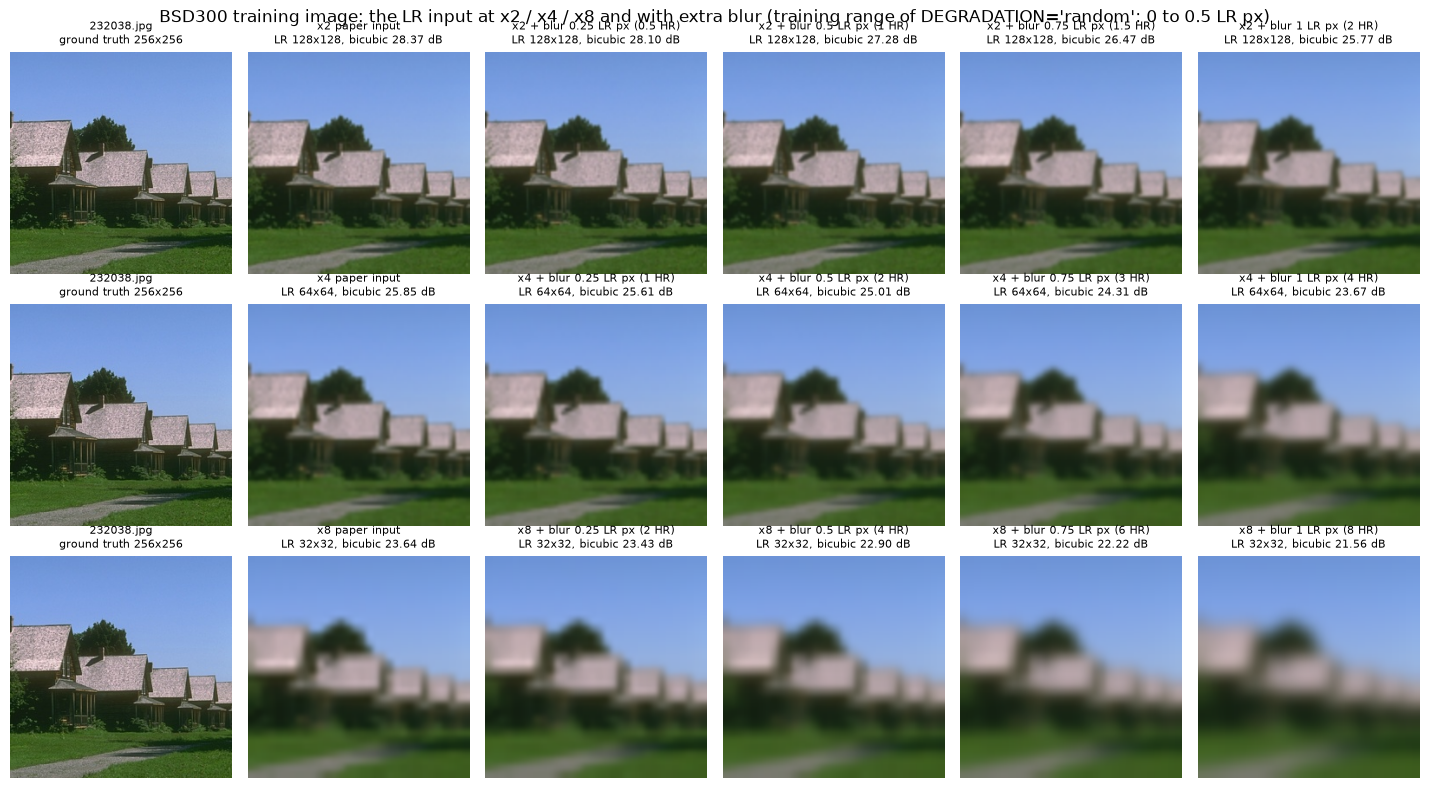

In [8]:
def lr_detail(hr, s, sigma, lr_filter=None):
    """LR input of a PIL HR image (extra blur sigma in LR px), its bicubic up-scaling, and that up-scaling's PSNR [dB]."""
    lr = make_lr(blur_hr(hr, sigma * s), s, lr_filter)
    up = np.asarray(lr.resize(hr.size, Image.Resampling.BICUBIC), dtype=np.float64)
    return lr, up, 10 * np.log10(255 ** 2 / np.mean((up - np.asarray(hr, dtype=np.float64)) ** 2))


def degradation_preview(paths, sigmas, scales=(2, 4, 8)):
    """For each image and scale: the ground truth next to the LR input at every blur sigma (LR pixels), each LR image
    bicubic-upscaled to the HR size so the blur can be compared. Titles: PSNR of that upscaling against the HR."""
    rows = [(path, s) for path in paths for s in scales]
    fig, axes = plt.subplots(len(rows), len(sigmas) + 1, figsize=(2.4 * (len(sigmas) + 1), 2.6 * len(rows)),
                             squeeze=False)
    for r, (path, s) in enumerate(rows):
        hr = make_hr(Image.open(path).convert("RGB"))
        axes[r, 0].imshow(hr)
        axes[r, 0].set_title(f"{path.name}\nground truth {hr.width}x{hr.height}", fontsize=8)
        for c, b in enumerate(sigmas, start=1):
            lr, up, p = lr_detail(hr, s, b)
            label = f"x{s} paper input" if b == 0 else f"x{s} + blur {b:g} LR px ({b * s:g} HR)"
            axes[r, c].imshow(up.astype(np.uint8))
            axes[r, c].set_title(f"{label}\nLR {lr.width}x{lr.height}, bicubic {p:.2f} dB", fontsize=8)
    for ax in axes.flat:
        ax.axis("off")
    plt.tight_layout()
    return fig


if MODE == "train":
    FIG_DIR = RUN_DIR / "figures"
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    sigmas = sorted({0.0, *BLUR_TEST, BLUR_MAX})
    hrs = [make_hr(Image.open(p).convert("RGB")) for p in train_files[:n_train][::5]]
    detail = pd.DataFrame([dict(filter=f, scale=f"x{s}", sigma_lr=b, psnr=np.mean([lr_detail(h, s, b, f)[2] for h in hrs]))
                           for f in RANDOM_FILTERS for s in (2, 4, 8) for b in sigmas])
    print(f"detail left in the LR input: PSNR [dB] of its bicubic up-scaling against the ground truth, mean over "
          f"{len(hrs)} {DATASET} training images (every 5th); blur sigma in LR px")
    display(detail.pivot_table(index=["filter", "sigma_lr"], columns="scale", values="psnr", sort=False).round(2))

    fig = degradation_preview([train_files[len(train_files) // 2]], sigmas)
    fig.suptitle(f"{DATASET} training image: the LR input at x2 / x4 / x8 and with extra blur "
                 f"(training range of DEGRADATION='random': 0 to {BLUR_MAX:g} LR px)", y=1.005)
    fig.savefig(FIG_DIR / "degradation_preview.png", dpi=80, bbox_inches="tight")
    plt.show()


## 4 Model: the modified U-net (paper §3.1, repo `Unet/Umodel.py`)

Three changes to the original U-net (Ronneberger et al. 2015):

1. **All batch-norm layers and one of the two convolutions in each block are removed.** Every block is a single
   3×3 conv + ReLU.
2. **The network takes the small LR image and grows it.** After the usual decoder returns to the LR size, it adds
   `log2(scale)` extra ×2 stages. Each extra stage gets its skip connection from a chain of ×2 transposed convolutions
   (`up_s1`, `up_s2`, …) applied to the first feature map. So a ×4 model has 2 extra stages and a ×8 model has 3, as
   in the paper.
3. **Depth 5** (encoder 64-128-256-512-512) is the accuracy/cost trade-off the paper picked (its Fig. 3).

```mermaid
flowchart LR
  LR["LR image 3 x h x w"] --> inc["inc: conv3x3+ReLU, 64"]
  inc --> d1["down1: maxpool + conv, 128"] --> d2["down2, 256"] --> d3["down3, 512"] --> d4["down4, 512 (bottleneck)"]
  d4 --> u1["up1 + skip down3, 256"] --> u2["up2 + skip down2, 128"] --> u3["up3 + skip down1, 64"] --> u4["up4 + skip inc, 32 (LR size)"]
  inc --> s1["up_s1: ConvT x2 + conv, 32"]
  u4 --> u5["up5 + skip up_s1 (2x size)"]
  s1 --> u5
  s1 -. "x4, x8" .-> s2["up_s2 ... up_s3"] -.-> u6["up6 ... up7 (4x, 8x size)"]
  u5 -.-> u6
  u5 --> out["outc: 1x1 conv, 3 (+ sigmoid for x4, x8)"]
  u6 -.-> out
```

The table below shows how the repo's three classes `UNet2`, `UNet4` and `UNet8` differ. `UNetSR(scale)` rebuilds all
three. It keeps the repo's module names, so the authors' weights load one-to-one (checked in the next cells).

| scale | LR in (`repo_crop` / `icdar_resize`) | decoder up-sampling | extra ×2 stages | widths of the extra stages | output | parameters |
|---|---|---|---|---|---|---|
| ×2 | 128² / 112² | transposed conv 2×2 | 1 | 32 | 1×1 conv, no activation | 8,495,907 |
| ×4 | 64² / 56² | transposed conv 2×2 | 2 | 16, 16 | 1×1 conv + sigmoid | 8,501,043 |
| ×8 | 32² / 28² | bilinear (`align_corners=True`) | 3 | 16, 8, 8 | 1×1 conv + sigmoid | 7,103,299 |

Faithfulness notes:
* The repo's `weight_init()` never reaches the conv layers, because it loops over the top-level blocks only. The
  authors therefore trained with **PyTorch's default initialisation**, and so does this notebook.
* In `up`, odd feature-map sizes are padded right/bottom before the skip concatenation. This is kept as in the repo.

In [9]:
class SingleConv(nn.Module):
    """3x3 conv + ReLU - the repo's `one_conv` (the vanilla U-net block minus batch-norm and its second conv)."""

    def __init__(self, cin, cout):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(cin, cout, 3, padding=1), nn.ReLU(inplace=True))

    def forward(self, x):
        return self.conv(x)


class InConv(nn.Module):
    """First block (repo `inconv`)."""

    def __init__(self, cin, cout):
        super().__init__()
        self.conv = SingleConv(cin, cout)

    def forward(self, x):
        return self.conv(x)


class Down(nn.Module):
    """2x2 max-pool then SingleConv (repo `down`)."""

    def __init__(self, cin, cout):
        super().__init__()
        self.mpconv = nn.Sequential(nn.MaxPool2d(2), SingleConv(cin, cout))

    def forward(self, x):
        return self.mpconv(x)


class Up(nn.Module):
    """x2 up-sampling, pad to the skip tensor's size, concatenate [skip, x], SingleConv (repo `up`)."""

    def __init__(self, cin, cout, bilinear):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(cin // 2, cin // 2, 2, stride=2)
        self.conv = SingleConv(cin, cout)

    def forward(self, x, skip):
        x = self.up(x)
        dy, dx = skip.size(2) - x.size(2), skip.size(3) - x.size(3)
        x = F.pad(x, (dx // 2, dx - dx // 2, dy // 2, dy - dy // 2))
        return self.conv(torch.cat([skip, x], dim=1))


class SkipUp(nn.Module):
    """x2 transposed conv + SingleConv (repo `up_s`): makes the skip features for the new, larger-scale blocks."""

    def __init__(self, cin, cout):
        super().__init__()
        self.upconv = nn.Sequential(nn.ConvTranspose2d(cin, cin, 2, stride=2), SingleConv(cin, cout))

    def forward(self, x):
        return self.upconv(x)


class OutConv(nn.Module):
    """1x1 conv to RGB (repo `outconv`)."""

    def __init__(self, cin, cout):
        super().__init__()
        self.conv = nn.Conv2d(cin, cout, 1)

    def forward(self, x):
        return self.conv(x)


class UNetSR(nn.Module):
    """The paper's modified U-net for x2 / x4 / x8 (equivalent to the repo's UNet2 / UNet4 / UNet8)."""

    # decoder up-sampling, output sigmoid, widths of the up_s skip chain and of the extra decoder stages
    CONFIG = {2: dict(bilinear=False, sigmoid=False, skip=(32,), dec=(32,)),
              4: dict(bilinear=False, sigmoid=True, skip=(32, 16), dec=(16, 16)),
              8: dict(bilinear=True, sigmoid=True, skip=(32, 16, 8), dec=(16, 8, 8))}

    def __init__(self, scale, in_ch=3, out_ch=3):
        super().__init__()
        cfg = self.CONFIG[scale]
        b = cfg["bilinear"]
        self.scale, self.sigmoid, self.n_extra = scale, cfg["sigmoid"], len(cfg["skip"])
        self.inc = InConv(in_ch, 64)
        self.down1, self.down2 = Down(64, 128), Down(128, 256)
        self.down3, self.down4 = Down(256, 512), Down(512, 512)
        self.up1, self.up2 = Up(1024, 256, b), Up(512, 128, b)
        self.up3, self.up4 = Up(256, 64, b), Up(128, 32, b)
        prev, skip_in = 32, 64
        for k, (s, d) in enumerate(zip(cfg["skip"], cfg["dec"]), start=1):
            setattr(self, f"up{4 + k}", Up(prev + s, d, b))     # repo names: up5, up6, up7
            setattr(self, f"up_s{k}", SkipUp(skip_in, s))      # repo names: up_s1, up_s2, up_s3
            prev, skip_in = d, s
        self.outc = OutConv(prev, out_ch)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        y = self.up4(self.up3(self.up2(self.up1(x5, x4), x3), x2), x1)   # back at the LR size
        s = x1
        for k in range(1, self.n_extra + 1):                            # each stage doubles the size
            s = getattr(self, f"up_s{k}")(s)
            y = getattr(self, f"up{4 + k}")(y, s)
        y = self.outc(y)
        return torch.sigmoid(y) if self.sigmoid else y

In [10]:
EXPECTED_PARAMS = {2: 8_495_907, 4: 8_501_043, 8: 7_103_299}   # paper Table 3 / Fig. 3: 8.50 M
with torch.no_grad():
    for s in (2, 4, 8):
        net = UNetSR(s)
        n = sum(p.numel() for p in net.parameters())
        y = net(torch.rand(1, 3, 27, 41))                              # odd LR sizes still give s-times larger outputs
        assert n == EXPECTED_PARAMS[s] and y.shape == (1, 3, 27 * s, 41 * s), (s, n, y.shape)
        print(f"x{s}: {n:,} parameters; LR 27x41 (HxW) -> SR {y.shape[-2]}x{y.shape[-1]}")

REPO_ROOT = NOTEBOOK_DIR.parent
sys.dont_write_bytecode = True                                     # keep the original repo free of __pycache__ files
if (REPO_ROOT / "Unet" / "Umodel.py").exists():
    if str(REPO_ROOT) not in sys.path:
        sys.path.append(str(REPO_ROOT))
    from Unet.Umodel import UNet2, UNet4, UNet8                      # the authors' original classes
    for s, cls in ((2, UNet2), (4, UNet4), (8, UNet8)):
        ref, ours = cls(3, 3).eval(), UNetSR(s).eval()
        ours.load_state_dict(ref.state_dict(), strict=True)            # identical parameter names and shapes
        x = torch.rand(2, 3, 28, 36)
        with torch.no_grad():
            diff = (ref(x) - ours(x)).abs().max().item()
        assert diff <= 1e-6, diff
        print(f"x{s}: same outputs as the repo's {cls.__name__} with the same weights (max |diff| = {diff:.1e})")
else:
    print("Repository code (../Unet) not found - skipping the equivalence check.")

x2: 8,495,907 parameters; LR 27x41 (HxW) -> SR 54x82
x4: 8,501,043 parameters; LR 27x41 (HxW) -> SR 108x164
x8: 7,103,299 parameters; LR 27x41 (HxW) -> SR 216x328


x2: same outputs as the repo's UNet2 with the same weights (max |diff| = 0.0e+00)


x4: same outputs as the repo's UNet4 with the same weights (max |diff| = 0.0e+00)


x8: same outputs as the repo's UNet8 with the same weights (max |diff| = 0.0e+00)


## 5 Metrics (paper §4.2)
The paper reports **PSNR and SSIM on the three RGB channels**:

* **PSNR** = 10·log10(255² / MSE), computed per image on the whole RGB ground truth (256×256 with `repo_crop`,
  224×224 with `icdar_resize`) and then averaged over the test set.
  This equals 10·log10(1 / MSE) on [0, 1] tensors, which is how the repo computes it.
* **SSIM** uses a Gaussian 11×11 window (σ = 1.5) with zero "same" padding and averages over channels and pixels.
  This is exactly the repo's `pytorch_ssim`; the parity check below compares the two.

Following the repo, model outputs are **not clamped** for these "paper" metrics. Only the ×2 model has an unbounded
output; ×4 and ×8 end in a sigmoid.

For reference, the cell also computes the usual SR-literature variant: **Y channel** (ITU-R BT.601), outputs clamped
and rounded to 8 bit, `scale` border pixels shaved, and SSIM without padding. These numbers are *not* comparable with
the paper's table.

In [11]:
def gaussian_window(size=11, sigma=1.5, channels=3, device=None, dtype=torch.float32):
    coords = torch.arange(size, dtype=torch.float64) - size // 2
    g = torch.exp(-coords ** 2 / (2 * sigma ** 2))
    g = g / g.sum()
    return (g[:, None] @ g[None, :]).to(dtype).expand(channels, 1, size, size).contiguous().to(device)


def ssim(x, y, window_size=11, sigma=1.5, padding="same", per_image=False):
    """SSIM of [B,C,H,W] tensors in [0,1]; padding="same" reproduces the repo's pytorch_ssim."""
    c = x.shape[1]
    w = gaussian_window(window_size, sigma, c, x.device, x.dtype)
    pad = window_size // 2 if padding == "same" else 0
    mu_x, mu_y = F.conv2d(x, w, padding=pad, groups=c), F.conv2d(y, w, padding=pad, groups=c)
    var_x = F.conv2d(x * x, w, padding=pad, groups=c) - mu_x ** 2
    var_y = F.conv2d(y * y, w, padding=pad, groups=c) - mu_y ** 2
    cov = F.conv2d(x * y, w, padding=pad, groups=c) - mu_x * mu_y
    c1, c2 = 0.01 ** 2, 0.03 ** 2
    m = ((2 * mu_x * mu_y + c1) * (2 * cov + c2)) / ((mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2))
    return m.flatten(1).mean(1) if per_image else m.mean()


def psnr(x, y):
    """Per-image PSNR in dB of [B,C,H,W] tensors in [0,1] (peak 1)."""
    mse = ((x - y) ** 2).flatten(1).mean(1)
    return 10 * torch.log10(1.0 / mse)


def rgb_to_y(x):
    """ITU-R BT.601 luma of [B,3,H,W] RGB in [0,1] -> [B,1,H,W] in [0,1] (16..235 range, as Matlab's rgb2ycbcr)."""
    return (16.0 + 65.481 * x[:, 0] + 128.553 * x[:, 1] + 24.966 * x[:, 2]).unsqueeze(1) / 255.0


def quantize(x):
    return x.clamp(0, 1).mul(255).round().div(255)


def all_metrics(sr, hr, scale=None):
    """Paper metrics (RGB, no clamp) and literature-style Y metrics (8-bit, shave=scale) for a batch."""
    scale = scale or SCALE
    sr, hr = sr.float(), hr.float()
    ys, yh = rgb_to_y(quantize(sr)), rgb_to_y(quantize(hr))
    ys, yh = ys[..., scale:-scale, scale:-scale], yh[..., scale:-scale, scale:-scale]
    return dict(psnr=psnr(sr, hr), ssim=ssim(sr, hr, per_image=True),
                psnr_y=psnr(ys, yh), ssim_y=ssim(ys, yh, padding="valid", per_image=True))

In [12]:
# parity with the repository's own SSIM implementation (pytorch_ssim)
if (REPO_ROOT / "pytorch_ssim" / "__init__.py").exists():
    import pytorch_ssim
    a, b = torch.rand(2, 3, 64, 64), torch.rand(2, 3, 64, 64)
    b = (0.7 * a + 0.3 * b).clamp(0, 1)
    d = abs(pytorch_ssim.ssim(a, b).item() - ssim(a, b).item())
    assert d < 1e-6, d
    print(f"SSIM matches the repo's pytorch_ssim (|diff| = {d:.1e})")

SSIM matches the repo's pytorch_ssim (|diff| = 0.0e+00)

## 6 Losses (paper §3.2)

* **UnetSR** is trained with plain **MSE** (paper eq. 1).
* **UnetSR+** is trained with the **mixed gradient error**, MixGE = MSE + λ<sub>G</sub>·MGE (eq. 6), where:
  * G = √(G<sub>x</sub>² + G<sub>y</sub>²) is the Sobel gradient magnitude (eqs. 2–4);
  * MGE is the mean squared difference between the gradient maps of the output and of the ground truth (eq. 5).

**How big is the MGE term? (`SOBEL_NORM`)** The paper prints the raw Sobel kernels (±1/±2) and the best weight
λ<sub>G</sub> = 0.1. It also calls MSE the *main* component and MGE an *auxiliary* one. Taken literally, those two
statements disagree. Measured on the bicubic outputs of the 100 BSD300 test images (section 7 prints the same ratio
for your run):

* **Raw kernels** (`SOBEL_NORM = False`): 0.1·MGE is **2.5–3× the MSE**.
* **Kernels divided by 8** (`SOBEL_NORM = True`, the usual normalisation, under which a ramp of slope 1 has a
  gradient of 1): 0.1·MGE is **0.04–0.05× the MSE**, an auxiliary term.

The authors' own (unused) `Unet/GraLoss.py` also shrinks its gradient terms, dividing them by 100 and 10 000. On
the same images it comes to 0.3–0.4× the MSE, between the two readings, so it does not settle the question.

A ×8 BSD300 ablation (15 epochs, same seed, CPU) does:

| loss | test PSNR | test SSIM |
|---|---|---|
| MSE | 21.17 | 0.510 |
| MixGE, raw kernels | 20.76 | 0.461 |
| **MixGE, normalised** | **21.45** | **0.513** |
| *(bicubic)* | *21.34* | *0.495* |

Only the normalised variant behaves as the paper reports (MixGE better than MSE, Fig. 4), so it is the default.
Raw kernels with λ<sub>G</sub> = 0.1 equal normalised kernels with λ<sub>G</sub> = 6.4 (up to the tiny ε below).

Other choices the paper leaves open:

* the Sobel filter runs on every RGB channel separately, with no padding (a "valid" convolution);
* a tiny ε = 1e-6 inside the square root keeps the gradient finite on flat regions;
* losses are always computed in float32.

`l1_ssim` is the loss that the repo's `Unet/solver.py` actually optimises: L1 + 0.1·(1 − SSIM). Its Sobel
`GradientLoss` is computed but never used, and it applies the second kernel to the output of the first, so it is not
the paper's MGE.

In [13]:
SOBEL_X = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]])    # paper eq. (2)
SOBEL_Y = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]])    # paper eq. (3)


def gradient_magnitude(img, normalize=None, eps=1e-6):
    """Sobel gradient magnitude sqrt(Gx^2 + Gy^2) of every channel (paper eq. 4); output is 2 px smaller.

    normalize=None uses the current SOBEL_NORM (kernels / 8 when True)."""
    normalize = SOBEL_NORM if normalize is None else normalize
    c = img.shape[1]
    kernels = torch.stack([SOBEL_X, SOBEL_Y]).unsqueeze(1).repeat(c, 1, 1, 1).to(img)   # [2C,1,3,3] = (x, y) per channel
    if normalize:
        kernels = kernels / 8.0
    g = F.conv2d(img, kernels, groups=c)
    return torch.sqrt(g[:, 0::2] ** 2 + g[:, 1::2] ** 2 + eps)


def mge(sr, hr):
    """Mean gradient error (paper eq. 5)."""
    return F.mse_loss(gradient_magnitude(sr), gradient_magnitude(hr))


def make_criterion(name, lambda_g=None):
    lambda_g = LAMBDA_G if lambda_g is None else lambda_g
    if name == "mse":                                       # UnetSR
        return lambda sr, hr: F.mse_loss(sr, hr)
    if name == "mixge":                                     # UnetSR+ (paper eq. 6)
        return lambda sr, hr: F.mse_loss(sr, hr) + lambda_g * mge(sr, hr)
    if name == "l1_ssim":                                   # repo Unet/solver.py
        return lambda sr, hr: F.l1_loss(sr, hr) + 0.1 * (1 - ssim(sr, hr))
    raise ValueError(name)


# sanity check: finite gradients even on flat (zero-gradient) or saturated images
for name in ("mse", "mixge", "l1_ssim"):
    x = torch.zeros(1, 3, 32, 32, requires_grad=True)
    make_criterion(name)(x, torch.ones(1, 3, 32, 32)).backward()
    assert torch.isfinite(x.grad).all(), name
print("losses OK:", ", ".join(("mse", "mixge", "l1_ssim")))

losses OK: mse, mixge, l1_ssim


## 7 Bicubic baseline vs the paper

The paper's Table 2 is reproduced below. Its **bicubic** row needs no training, so it tests whether our pairs are
prepared exactly like the authors' were. With the default protocol it matches:

* SET14: to the fourth decimal;
* BSD300: within 0.035 dB.

That means any remaining gap to the paper's network results comes from training, not from pre-processing.

In [14]:
# Paper Table 2 (arXiv:1911.09428v1, p. 12): PSNR [dB] / SSIM on RGB
PAPER_TABLE2_TXT = """
method  scale SET14_psnr SET14_ssim BSD300_psnr BSD300_ssim ICDAR2003_psnr ICDAR2003_ssim
Bicubic 2 24.4523 0.8482 26.6538 0.7924 32.9327 0.9028
ESPCN   2 26.7606 0.8999 28.9832 0.8732 35.6041 0.9243
SRCNN   2 25.9711 0.8681 28.6943 0.8671 35.2711 0.9234
VDSR    2 28.6617 0.9269 29.3889 0.8785 36.2323 0.9375
EDSR    2 24.0624 0.8383 28.3119 0.8621 34.5047 0.9258
FSRCNN  2 23.1284 0.8123 28.7534 0.8681 35.0533 0.9355
DRCN    2 24.4234 0.8458 27.5089 0.8088 33.7849 0.9185
SRGAN   2 23.9553 0.8195 28.7072 0.8633 33.2834 0.9135
DBPN    2 28.4092 0.9202 29.8675 0.8834 36.2344 0.9401
UnetSR  2 26.7241 0.8735 29.4241 0.8813 35.7147 0.9388
UnetSR+ 2 28.3965 0.9198 29.8403 0.8816 37.3673 0.9675
Bicubic 4 19.7167 0.6089 23.5053 0.6157 28.1135 0.7875
ESPCN   4 20.6292 0.6333 24.4899 0.6641 29.4861 0.8214
SRCNN   4 20.5825 0.6288 24.2232 0.6597 28.1906 0.7661
VDSR    4 21.4763 0.6991 24.7077 0.6816 30.5267 0.8321
EDSR    4 19.9784 0.6269 23.9192 0.6513 27.9723 0.7101
FSRCNN  4 19.3255 0.5941 24.2499 0.6599 28.0231 0.7652
DRCN    4 19.7077 0.6078 23.3462 0.6132 27.7174 0.7764
SRGAN   4 19.3877 0.5976 24.1675 0.6485 27.5605 0.7654
DBPN    4 21.7657 0.7171 25.0644 0.6967 29.8832 0.8224
UnetSR  4 20.8891 0.6693 24.8332 0.6843 29.3374 0.8202
UnetSR+ 4 21.6825 0.7112 24.9522 0.6901 31.8966 0.8898
Bicubic 8 16.1132 0.3673 21.3115 0.4933 24.3856 0.6831
ESPCN   8 16.3441 0.3628 21.6447 0.5064 25.1132 0.6964
SRCNN   8 16.3853 0.3614 21.8101 0.5075 22.6281 0.6103
VDSR    8 16.7994 0.4095 21.9697 0.5181 25.6303 0.7104
EDSR    8 15.7257 0.3209 21.6573 0.5067 23.5578 0.5987
FSRCNN  8 14.5788 0.2541 21.3311 0.5011 22.5721 0.6155
DRCN    8 16.1497 0.3685 21.2771 0.4934 24.2561 0.6725
SRGAN   8 15.7133 0.3221 21.8766 0.5121 23.5621 0.6425
DBPN    8 16.7398 0.4122 22.0577 0.5229 26.3482 0.7196
UnetSR  8 16.7001 0.4093 21.9865 0.5231 25.7734 0.7106
UnetSR+ 8 17.8289 0.4103 22.0368 0.5235 28.2512 0.8101
"""
_rows = [line.split() for line in PAPER_TABLE2_TXT.strip().splitlines()[1:]]
PAPER = {(m, int(s), ds): (float(v[2 * i]), float(v[2 * i + 1]))
         for m, s, *v in _rows for i, ds in enumerate(("SET14", "BSD300", "ICDAR2003"))}
PAPER_METHOD = {"mse": "UnetSR", "mixge": "UnetSR+"}.get(LOSS)                     # l1_ssim has no paper row
NO_PAPER = (float("nan"), float("nan"))                                             # e.g. SET14_ALL


def bicubic_upscale(lr, size):
    """Bicubic up-scaling of a [B,3,h,w] batch in [0,1] with Pillow (the repo's baseline uses Pillow too)."""
    out = []
    for img in lr:
        pil = Image.fromarray(img.mul(255).round().byte().permute(1, 2, 0).cpu().numpy())
        out.append(to_uint8_tensor(pil.resize((size, size), Image.Resampling.BICUBIC)).float().div(255))
    return torch.stack(out).to(lr.device)


@torch.no_grad()
def evaluate(upscale_fn, dataset, scale=None, device=None, batch_size=8):
    """Per-image metrics of `upscale_fn` (a model or bicubic) on an SRPairs dataset."""
    scale, device = scale or SCALE, device or DEVICE
    rows = []
    for start in range(0, len(dataset), batch_size):
        idx = range(start, min(start + batch_size, len(dataset)))
        lr = torch.stack([dataset[i][0] for i in idx]).to(device)
        hr = torch.stack([dataset[i][1] for i in idx]).to(device)
        m = all_metrics(upscale_fn(lr), hr, scale)
        for j, i in enumerate(idx):
            rows.append(dict(image=dataset.names[i], **{k: v[j].item() for k, v in m.items()}))
    return pd.DataFrame(rows)


def bicubic_fn(lr):
    return bicubic_upscale(lr, lr.shape[-1] * SCALE)


if MODE == "train":
    rows = []
    for name, ds in test_sets.items():
        res = evaluate(bicubic_fn, ds)
        p_psnr, p_ssim = PAPER.get(("Bicubic", SCALE, name), NO_PAPER)
        rows.append(dict(set=name, protocol=TEST_PROTOCOL[name], images=len(ds), psnr=res.psnr.mean(),
                         paper_psnr=p_psnr, d_psnr=res.psnr.mean() - p_psnr, ssim=res.ssim.mean(), paper_ssim=p_ssim,
                         d_ssim=res.ssim.mean() - p_ssim))
    BICUBIC_VS_PAPER = pd.DataFrame(rows)
    print(f"Bicubic x{SCALE} (protocols: section 3)")
    display(BICUBIC_VS_PAPER.round(4))


@torch.no_grad()
def mge_to_mse_ratio(dataset, lambda_g=None, batch_size=8):
    """Median over images of lambda_g * MGE / MSE for the bicubic outputs, with raw and with /8 Sobel kernels."""
    lambda_g = LAMBDA_G if lambda_g is None else lambda_g
    ratios = {False: [], True: []}
    for start in range(0, len(dataset), batch_size):
        idx = range(start, min(start + batch_size, len(dataset)))
        lr = torch.stack([dataset[i][0] for i in idx])
        hr = torch.stack([dataset[i][1] for i in idx])
        sr = bicubic_fn(lr)
        mse_i = (sr - hr).pow(2).flatten(1).mean(1)
        for norm, acc in ratios.items():
            mge_i = (gradient_magnitude(sr, norm) - gradient_magnitude(hr, norm)).pow(2).flatten(1).mean(1)
            acc.extend((lambda_g * mge_i / mse_i).tolist())
    return {norm: float(np.median(acc)) for norm, acc in ratios.items()}


if MODE == "train":                                         # the MGE scale question of section 6, on your data
    for name, ds in test_sets.items():
        r = mge_to_mse_ratio(ds)
        print(f"{name}: {LAMBDA_G} * MGE / MSE on the bicubic outputs = {r[False]:.2f} with raw Sobel kernels, "
              f"{r[True]:.3f} with kernels / 8 (this run: SOBEL_NORM = {SOBEL_NORM})")

Bicubic x4 (protocols: section 3)


,set,protocol,images,psnr,paper_psnr,d_psnr,ssim,paper_ssim,d_ssim
0,BSD300,repo_crop,100,23.5402,23.5053,0.0349,0.6178,0.6157,0.0021


BSD300: 0.1 * MGE / MSE on the bicubic outputs = 3.05 with raw Sobel kernels, 0.048 with kernels / 8 (this run: SOBEL_NORM = True)


### 7b Protocol study (`MODE = "calibrate"`)
Run the notebook with `MODE = "calibrate"` (`-p MODE calibrate` in papermill) to evaluate the bicubic baseline under
8 pre-processing variants, on every available dataset and scale:

* ground-truth size: 224 or 256;
* how it is cut from the photo: centre crop or whole-image resize;
* LR filter: bilinear or bicubic.

The result goes to `results/bicubic_calibration.csv` and is reported in the README:

* **SET14 (3 test images)** with `repo_crop` matches the paper to 4 decimals in all six numbers (PSNR and SSIM at ×2,
  ×4 and ×8).
* **BSD300** with `repo_crop` matches within +0.035 dB and +0.0021.
* **SET14_ALL**, all 14 images, cannot match: it has no paper row.
* **Which images are the paper's SET14 test set?** A search over all 16,383 subsets of the 14 images (with
  `repo_crop`) finds that only comic + monarch + zebra reproduces the paper's six SET14 bicubic numbers. The ranking
  goes to `results/set14_subset_search.csv`.
* The 224-pixel bicubic "paper_text" variant is too high: by 0.68 to 1.63 dB on BSD300 and 0.25 to 1.52 dB on SET14.

Run it on your own machine once ICDAR2003 has downloaded, to find the ICDAR2003 protocol. `icdar_resize` is the
default, but it is untested. This mode does not try to download ICDAR2003 itself; run
`uv run python download_datasets.py --datasets icdar2003` first.

In [15]:
def bicubic_protocol_study(datasets, scales=(2, 4, 8), sizes=(224, 256), modes=("crop", "resize"),
                           filters=("bilinear", "bicubic")):
    named = {(v["hr_size"], v["hr_mode"], v["lr_filter"]): k for k, v in PROTOCOLS.items()}
    rows = []
    for name in datasets:
        originals = [Image.open(p).convert("RGB") for p in split_files(name, "test")]
        for size in sizes:
            for mode in modes:
                hrs = [make_hr(img, size, mode) for img in originals]
                for lr_filter in filters:
                    for s in scales:
                        psnrs, ssims = [], []
                        for i in range(0, len(hrs), 16):      # 16 images at a time keeps the memory use small
                            chunk = hrs[i:i + 16]
                            hr_t = torch.stack([to_uint8_tensor(h) for h in chunk]).float().div(255)
                            lr_t = torch.stack([to_uint8_tensor(make_lr(h, s, lr_filter)) for h in chunk]).float().div(255)
                            m = all_metrics(bicubic_upscale(lr_t, size), hr_t, s)
                            psnrs.append(m["psnr"])
                            ssims.append(m["ssim"])
                        p_psnr, p_ssim = PAPER.get(("Bicubic", s, name), NO_PAPER)
                        rows.append(dict(set=name, images=len(originals), scale=s, hr_size=size, hr_mode=mode,
                                         lr_filter=lr_filter, protocol=named.get((size, mode, lr_filter), ""),
                                         psnr=torch.cat(psnrs).mean().item(), ssim=torch.cat(ssims).mean().item(),
                                         paper_psnr=p_psnr, paper_ssim=p_ssim))
    df = pd.DataFrame(rows)
    df["d_psnr"], df["d_ssim"] = df.psnr - df.paper_psnr, df.ssim - df.paper_ssim
    return df


if MODE == "calibrate":
    calib = bicubic_protocol_study([*AVAILABLE, *(["SET14_ALL"] if "SET14" in AVAILABLE else [])])
    Path("results").mkdir(exist_ok=True)
    calib.round(4).to_csv("results/bicubic_calibration.csv", index=False)
    with_paper = calib.dropna(subset=["paper_psnr"])
    summary = (with_paper.assign(abs_d_psnr=with_paper.d_psnr.abs(), abs_d_ssim=with_paper.d_ssim.abs())
               .groupby(["set", "hr_size", "hr_mode", "lr_filter", "protocol"])[["abs_d_psnr", "abs_d_ssim"]]
               .max().sort_values(["set", "abs_d_psnr"]))
    print("largest |difference| to the paper's bicubic row over x2/x4/x8, per dataset and variant:")
    display(summary.round(4))
    display(calib.pivot_table(index=["hr_size", "hr_mode", "lr_filter"], columns=["set", "scale"],
                              values="psnr").round(2))
    print("saved results/bicubic_calibration.csv")


def set14_subset_search(scales=(2, 4, 8), top=10):
    """Rank every subset of the 14 Set14 images by how well its bicubic mean matches the paper's SET14 row."""
    from itertools import combinations
    files = split_files("SET14_ALL", "test")
    per_image = {}                                          # scale -> (PSNR array, SSIM array) over the 14 images
    for s in scales:
        _, lr, hr = load_pairs(files, scale=s, protocol="repo_crop")
        m = all_metrics(bicubic_upscale(lr.float().div(255), hr.shape[-1]), hr.float().div(255), s)
        per_image[s] = (m["psnr"].numpy(), m["ssim"].numpy())
    rows = []
    for k in range(1, len(files) + 1):
        for idx in map(list, combinations(range(len(files)), k)):
            d_psnr = [per_image[s][0][idx].mean() - PAPER[("Bicubic", s, "SET14")][0] for s in scales]
            d_ssim = [per_image[s][1][idx].mean() - PAPER[("Bicubic", s, "SET14")][1] for s in scales]
            rows.append(dict(images=" ".join(files[i].stem for i in idx), n_images=k,
                             max_abs_d_psnr=max(map(abs, d_psnr)), max_abs_d_ssim=max(map(abs, d_ssim))))
    return pd.DataFrame(rows).sort_values(["max_abs_d_psnr", "max_abs_d_ssim"]).head(top).reset_index(drop=True)


if MODE == "calibrate" and "SET14" in AVAILABLE:
    SUBSETS = set14_subset_search()
    SUBSETS.round(4).to_csv("results/set14_subset_search.csv", index=False)
    print("SET14 subsets closest to the paper's bicubic row (largest |difference| over x2/x4/x8):")
    display(SUBSETS.head(5).round(4))
    print("saved results/set14_subset_search.csv")

## 8 Training (paper §4.3)

* **Optimiser**: Adam (β = 0.9 / 0.999, ε = 1e-8), learning rate 1e-3 halved every 25 epochs, batch size 1.
* **Monitoring**: every `EVAL_EVERY` epochs the test sets are evaluated, as in the repo. This is for watching progress
  only; no checkpoint is selected on test data, and the reported model is always the **last epoch**.
* **Checkpoints and history**: `runs/<RUN_NAME>/last.pt` is rewritten after every epoch and holds the model,
  optimiser, scheduler and random-number states. Re-running the notebook with `RESUME = True` continues an
  interrupted run, on any device, and a larger `EPOCHS` extends a finished one. A run folder whose `last.pt` was
  trained with other settings is never overwritten silently: the notebook stops and asks for another `RUN_NAME` (or
  `RESUME = False`, which starts that folder from scratch). The history is saved to `runs/<RUN_NAME>/history.csv`.
* **Fine-tuning** (`FINETUNE_FROM = "<run name>"`): the run starts from that run's final weights instead of a fresh
  initialisation; both must have the same `SCALE`. With `DEGRADATION = "random"`, this adapts a paper-protocol model to
  varied blur (section 3b). The final grid fine-tunes with `-p LR 1e-4 -p EPOCHS 100`: a learning rate 10× below the
  paper's start, halved every 25 epochs as before. The run folder gets the tags `rand` and `ft`, and its `config.json`
  names the parent run.


In [16]:
def save_checkpoint(path, **state):
    tmp = path.with_suffix(".tmp")
    torch.save(state, tmp)
    os.replace(tmp, path)                                   # atomic: an interrupted save never corrupts last.pt


@torch.no_grad()
def quick_eval(model, sets):
    model.eval()
    out = {}
    for name, ds in sets.items():
        res = evaluate(model, ds)
        out[f"{name}_psnr"], out[f"{name}_ssim"] = res.psnr.mean(), res.ssim.mean()
    model.train()
    return out


if MODE == "train":
    seed_everything(SEED)                                   # identical initial weights for every run with this seed
    model = UNetSR(SCALE).to(DEVICE)
    PARENT_WEIGHTS = None
    if FINETUNE_FROM:                                       # start from another run's final weights (section 8)
        parent_cfg = json.loads((RUNS_DIR / FINETUNE_FROM / "config.json").read_text())
        assert parent_cfg["SCALE"] == SCALE, f"{FINETUNE_FROM} is a x{parent_cfg['SCALE']} model, this run is x{SCALE}"
        PARENT_WEIGHTS = RUNS_DIR / FINETUNE_FROM / f"unetsr_x{SCALE}_{parent_cfg['LOSS']}.pt"
        model.load_state_dict(torch.load(PARENT_WEIGHTS, weights_only=True))
        print(f"fine-tuning from {PARENT_WEIGHTS} ({parent_cfg['LOSS']}, "
              f"{parent_cfg.get('DEGRADATION', 'fixed')} degradation)")
    criterion = make_criterion(LOSS)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.999), eps=1e-8, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)
    loader_rng = torch.Generator().manual_seed(SEED)
    loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                                         generator=loader_rng, pin_memory=DEVICE.type == "cuda")

    RUN_DIR.mkdir(parents=True, exist_ok=True)
    ckpt_path, hist_path = RUN_DIR / "last.pt", RUN_DIR / "history.csv"
    history = []
    if RESUME and ckpt_path.exists():
        # Load on the CPU: the random-number states must stay CPU tensors; load_state_dict moves the rest to DEVICE.
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
        saved = {k: ckpt["config"].get(k, DEFAULTS.get(k)) for k in RESUME_KEYS}
        changed = {k: (saved[k], CFG[k]) for k in RESUME_KEYS if saved[k] != CFG[k]}
        if changed:
            raise RuntimeError(
                f"{ckpt_path} was trained with other settings ("
                + ", ".join(f"{k}: {old!r} there, {new!r} now" for k, (old, new) in changed.items())
                + "). Use another RUN_NAME (or leave it at None: the default name encodes the settings), "
                  "or set RESUME = False to start this folder from scratch.")
        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])
        torch.set_rng_state(ckpt["rng_cpu"])
        loader_rng.set_state(ckpt["rng_loader"])
        if DEVICE.type == "cuda" and ckpt.get("rng_cuda") is not None:
            torch.cuda.set_rng_state_all(ckpt["rng_cuda"])
        history = pd.read_csv(hist_path).to_dict("records") if hist_path.exists() else []
        history = [h for h in history if h["epoch"] <= ckpt["epoch"]]
        print(f"resuming {RUN_NAME} after epoch {ckpt['epoch']}")
    elif ckpt_path.exists():
        print(f"RESUME = False: training {RUN_NAME} from scratch; its old checkpoint will be replaced")
    (RUN_DIR / "config.json").write_text(json.dumps(CFG, indent=1))
    print(f"{RUN_NAME}: {sum(p.numel() for p in model.parameters()):,} parameters, epochs "
          f"{scheduler.last_epoch + 1}..{EPOCHS}, {len(train_set)} images/epoch, device {DEVICE}, AMP {USE_AMP}")

fine-tuning from runs\BSD300_x4_mixge\unetsr_x4_mixge.pt (mixge, fixed degradation)


RESUME = False: training BSD300_x4_mixge_rand_ft_lr0.0001 from scratch; its old checkpoint will be replaced
BSD300_x4_mixge_rand_ft_lr0.0001: 8,501,043 parameters, epochs 1..100, 200 images/epoch, device cuda, AMP False


In [17]:
if MODE == "train":
    model.train()
    t_start = time.time()
    start_epoch = scheduler.last_epoch + 1           # epochs already trained + 1; also right after an interrupted cell
    if start_epoch > EPOCHS:
        print(f"{RUN_NAME} already has {start_epoch - 1} epochs (EPOCHS = {EPOCHS}) - nothing to train")
    for epoch in range(start_epoch, EPOCHS + 1):
        t_epoch = time.time()
        running = torch.zeros((), device=DEVICE)
        for lr_img, hr_img in tqdm(loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False):
            lr_img = lr_img.to(DEVICE, non_blocking=True)
            hr_img = hr_img.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=USE_AMP):
                sr = model(lr_img)
            loss = criterion(sr.float(), hr_img)                # losses always in float32
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            running += loss.detach() * lr_img.size(0)
        train_loss = running.item() / len(train_set)
        if not math.isfinite(train_loss):
            raise FloatingPointError(f"loss became {train_loss} in epoch {epoch} - try a lower LR or LOSS='mse'")
        row = dict(epoch=epoch, lr=optimizer.param_groups[0]["lr"], train_loss=train_loss,
                   epoch_seconds=time.time() - t_epoch)
        scheduler.step()
        evaluate_now = epoch == EPOCHS or (EVAL_EVERY > 0 and epoch % EVAL_EVERY == 0)
        if evaluate_now:
            row.update(quick_eval(model, test_sets))
        history.append(row)
        pd.DataFrame(history).to_csv(hist_path, index=False)
        save_checkpoint(ckpt_path, epoch=epoch, model=model.state_dict(), optimizer=optimizer.state_dict(),
                        scheduler=scheduler.state_dict(), rng_cpu=torch.get_rng_state(),
                        rng_loader=loader_rng.get_state(),
                        rng_cuda=torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else None, config=CFG)
        if epoch == start_epoch or evaluate_now:
            eta = (time.time() - t_start) / (epoch - start_epoch + 1) * (EPOCHS - epoch)
            scores = "  ".join(f"{k} {v:.4f}" for k, v in row.items() if k.endswith(("_psnr", "_ssim")))
            print(f"epoch {epoch:4d}  loss {train_loss:.5f}  lr {row['lr']:.2e}  {scores}  ({row['epoch_seconds']:.1f}s/epoch,"
                  f" ETA {eta / 60:.1f} min)")
    weights = {k: v.detach().cpu() for k, v in model.state_dict().items()}    # CPU tensors load on any machine
    torch.save(weights, RUN_DIR / f"unetsr_x{SCALE}_{LOSS}.pt")               # weights only, for inference (section 11)
    print(f"training finished in {(time.time() - t_start) / 60:.1f} min")

epoch 1/100:   0%|          | 0/200 [00:00<?, ?it/s]

epoch    1  loss 0.00468  lr 1.00e-04    (9.9s/epoch, ETA 16.6 min)


epoch 2/100:   0%|          | 0/200 [00:00<?, ?it/s]

epoch 3/100:   0%|          | 0/200 [00:00<?, ?it/s]

epoch 4/100:   0%|          | 0/200 [00:00<?, ?it/s]

...

epoch 97/100:   0%|          | 0/200 [00:00<?, ?it/s]

epoch 98/100:   0%|          | 0/200 [00:00<?, ?it/s]

epoch 99/100:   0%|          | 0/200 [00:00<?, ?it/s]

epoch 100/100:   0%|          | 0/200 [00:00<?, ?it/s]

epoch  100  loss 0.00459  lr 1.25e-05  BSD300_psnr 24.5464  BSD300_ssim 0.6751  (4.9s/epoch, ETA 0.0 min)
training finished in 9.1 min


## 9 Evaluation vs the paper

The final model is evaluated on every test set, together with the bicubic baseline under the same protocol, and
compared with the matching row of the paper's Table 2: UnetSR for `mse`, UnetSR+ for `mixge`. `l1_ssim` has no
paper row. Test sets of another dataset than `DATASET` (cross-dataset scores) get no verdict, because each paper row
is compared here with a model trained on that dataset's own training split.

The verdict thresholds are fixed in advance:

* **matches**: |ΔPSNR| ≤ 0.3 dB and |ΔSSIM| ≤ 0.01;
* **close**: |ΔPSNR| ≤ 1 dB;
* **differs**: anything else.

Two comparisons are made:

* **absolute**: our PSNR vs the paper's PSNR;
* **gain**: (ours − our bicubic) vs (paper − paper bicubic). This is more robust where the pre-processing is not
  reproduced exactly: section 7b matches SET14 exactly, BSD300 within 0.035 dB, and could not check ICDAR2003.

Everything is written to `runs/<RUN_NAME>/metrics.json` and `per_image_<set>.csv`.

**Blur sweep (minute 4c).** The model is also scored on the `DATASET` test split blurred by every σ in `BLUR_TEST`
(LR pixels) before the down-scaling. Bicubic is scored next to it and, for a fine-tuned run, the model it started from.
σ = 0 is exactly the paper's test set: section 3 checks that its LR images are identical. The result goes to
`blur_sweep.csv` and `metrics.json`, and section 10 plots it. The paper has no values for blurred inputs.


In [18]:
def verdict(d_psnr, d_ssim=None):
    if abs(d_psnr) <= 0.3 and (d_ssim is None or abs(d_ssim) <= 0.01):
        return "matches"
    return "close" if abs(d_psnr) <= 1.0 else "differs"


if MODE == "train":
    model.eval()
    results, rows = {}, []
    for name, ds in test_sets.items():
        ours, bic = evaluate(model, ds), evaluate(bicubic_fn, ds)
        ours.to_csv(RUN_DIR / f"per_image_{name}.csv", index=False)
        p_psnr, p_ssim = PAPER.get((PAPER_METHOD, SCALE, name), NO_PAPER)
        b_psnr, b_ssim = PAPER.get(("Bicubic", SCALE, name), NO_PAPER)
        cross = name != DATASET                  # another dataset (or the hold-out / all-14 variants)
        r = dict(set=name, images=len(ds), psnr=ours.psnr.mean(), ssim=ours.ssim.mean(),
                 psnr_y=ours.psnr_y.mean(), ssim_y=ours.ssim_y.mean(),
                 bicubic_psnr=bic.psnr.mean(), bicubic_ssim=bic.ssim.mean(),
                 paper_method=PAPER_METHOD, paper_psnr=p_psnr, paper_ssim=p_ssim,
                 paper_bicubic_psnr=b_psnr, paper_bicubic_ssim=b_ssim)
        r["d_psnr"], r["d_ssim"] = r["psnr"] - p_psnr, r["ssim"] - p_ssim
        r["gain_psnr"], r["paper_gain_psnr"] = r["psnr"] - r["bicubic_psnr"], p_psnr - b_psnr
        r["d_gain_psnr"] = r["gain_psnr"] - r["paper_gain_psnr"]
        if math.isnan(p_psnr):
            r["verdict_absolute"] = r["verdict_gain"] = "no paper value"
        elif cross:
            r["verdict_absolute"] = r["verdict_gain"] = f"none: model trained on {DATASET}"
        else:
            r["verdict_absolute"], r["verdict_gain"] = verdict(r["d_psnr"], r["d_ssim"]), verdict(r["d_gain_psnr"])
        r["protocol"] = TEST_PROTOCOL[name]
        if DATASET == "SET14" and name == "SET14_ALL":
            r["note"] = "includes the 11 training images"
        rows.append(r)
        results[name] = {k: (None if isinstance(v, float) and math.isnan(v) else
                             float(v) if isinstance(v, (float, np.floating)) else v) for k, v in r.items()}
    EVAL = pd.DataFrame(rows)
    if EVAL.empty:
        print("no test set available - nothing to evaluate (check EVAL_SETS and the data/ folder)")
    else:
        display(EVAL[["set", "images", "psnr", "paper_psnr", "d_psnr", "ssim", "paper_ssim", "d_ssim", "gain_psnr",
                      "paper_gain_psnr", "verdict_absolute", "verdict_gain"]].round(4))
    BLUR_NETS = {"bicubic": bicubic_fn}
    if PARENT_WEIGHTS:                                      # the model this run was fine-tuned from
        parent = UNetSR(SCALE).to(DEVICE).eval()
        parent.load_state_dict(torch.load(PARENT_WEIGHTS, weights_only=True))
        BLUR_NETS["before fine-tuning"] = parent
    BLUR_NETS["ours"] = model
    sweep_rows = []
    for b, ds in BLUR_SETS.items():
        for who, net in BLUR_NETS.items():
            res = evaluate(net, ds)
            sweep_rows.append(dict(sigma_lr=b, sigma_hr=b * SCALE, model=who, psnr=res.psnr.mean(),
                                   ssim=res.ssim.mean()))
    BLUR_SWEEP = pd.DataFrame(sweep_rows)
    if sweep_rows:
        BLUR_SWEEP.to_csv(RUN_DIR / "blur_sweep.csv", index=False)
        print(f"blur sweep, {DATASET} test split, PSNR [dB] by blur sigma [LR px] (x{SCALE} for HR px):")
        display(BLUR_SWEEP.pivot(index="model", columns="sigma_lr", values="psnr").loc[list(BLUR_NETS)].round(3))
    metrics = dict(config=CFG, results=results, blur_sweep=sweep_rows, epochs_trained=int(history[-1]["epoch"]) if history else 0,
                   train_seconds=float(sum(h["epoch_seconds"] for h in history)),
                   environment=dict(torch=torch.__version__, device=str(DEVICE),
                                    gpu=torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else None))
    (RUN_DIR / "metrics.json").write_text(json.dumps(metrics, indent=1))
    print(f"saved {RUN_DIR / 'metrics.json'}")

,set,images,psnr,paper_psnr,d_psnr,ssim,paper_ssim,d_ssim,gain_psnr,paper_gain_psnr,verdict_absolute,verdict_gain
0,BSD300,100,24.5464,24.9522,-0.4058,0.6751,0.6901,-0.015,1.0062,1.4469,close,close


blur sweep, BSD300 test split, PSNR [dB] by blur sigma [LR px] (x4 for HR px):


sigma_lr,0.00,0.25,0.50,0.75,1.00
model,,,,,
bicubic,23.540,23.270,22.623,21.913,21.289
before fine-tuning,24.551,24.416,23.528,22.433,21.573
ours,24.546,24.405,23.601,22.520,21.632


saved runs\BSD300_x4_mixge_rand_ft_lr0.0001\metrics.json


## 10 Visual results
* Training curves.
* Before and after: the LR input, its bicubic up-scaling (blurred) and our output next to the ground truth, with
  each image's PSNR. The images come from the test sets, never from the training split; the cell prints their
  names and folder.
* The Sobel gradient magnitude that MGE compares: sharper edges show up as brighter, thinner lines.
* The blur sweep: PSNR and SSIM against the blur σ for bicubic, our model and, for a fine-tuned run, the model before
  fine-tuning. The grey band is the training range of a `DEGRADATION = "random"` run.
* One test image at the mildest, the training-maximum and the strongest blur σ: what each model makes of it.

Figures are also saved to `runs/<RUN_NAME>/figures/`.

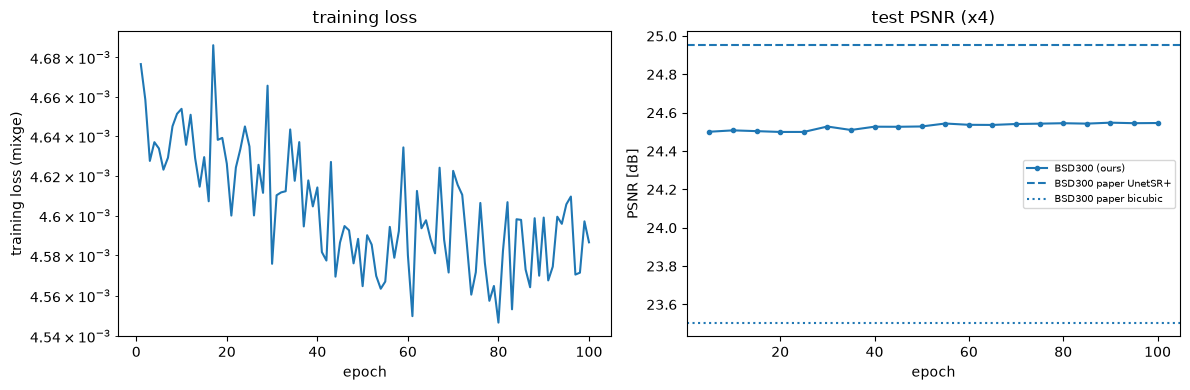

In [19]:
if MODE == "train":
    FIG_DIR = RUN_DIR / "figures"
    FIG_DIR.mkdir(exist_ok=True)
    hist = pd.DataFrame(history)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(hist.epoch, hist.train_loss)
    ax1.set(xlabel="epoch", ylabel=f"training loss ({LOSS})", yscale="log", title="training loss")
    for name in test_sets:
        col = f"{name}_psnr"
        if col in hist:
            h = hist.dropna(subset=[col])
            line, = ax2.plot(h.epoch, h[col], marker=".", label=f"{name} (ours)")
            if name == DATASET and (PAPER_METHOD, SCALE, name) in PAPER:
                ax2.axhline(PAPER[(PAPER_METHOD, SCALE, name)][0], ls="--", color=line.get_color(),
                            label=f"{name} paper {PAPER_METHOD}")
                ax2.axhline(PAPER[("Bicubic", SCALE, name)][0], ls=":", color=line.get_color(),
                            label=f"{name} paper bicubic")
    ax2.set(xlabel="epoch", ylabel="PSNR [dB]", title=f"test PSNR (x{SCALE})")
    ax2.legend(fontsize=7)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "curves.png", dpi=120)
    plt.show()

BSD300 examples: 101085.jpg, 241004.jpg, 97033.jpg - from the BSD300 test split (data\BSD300\test); none of them is among the 200 BSD300 training images


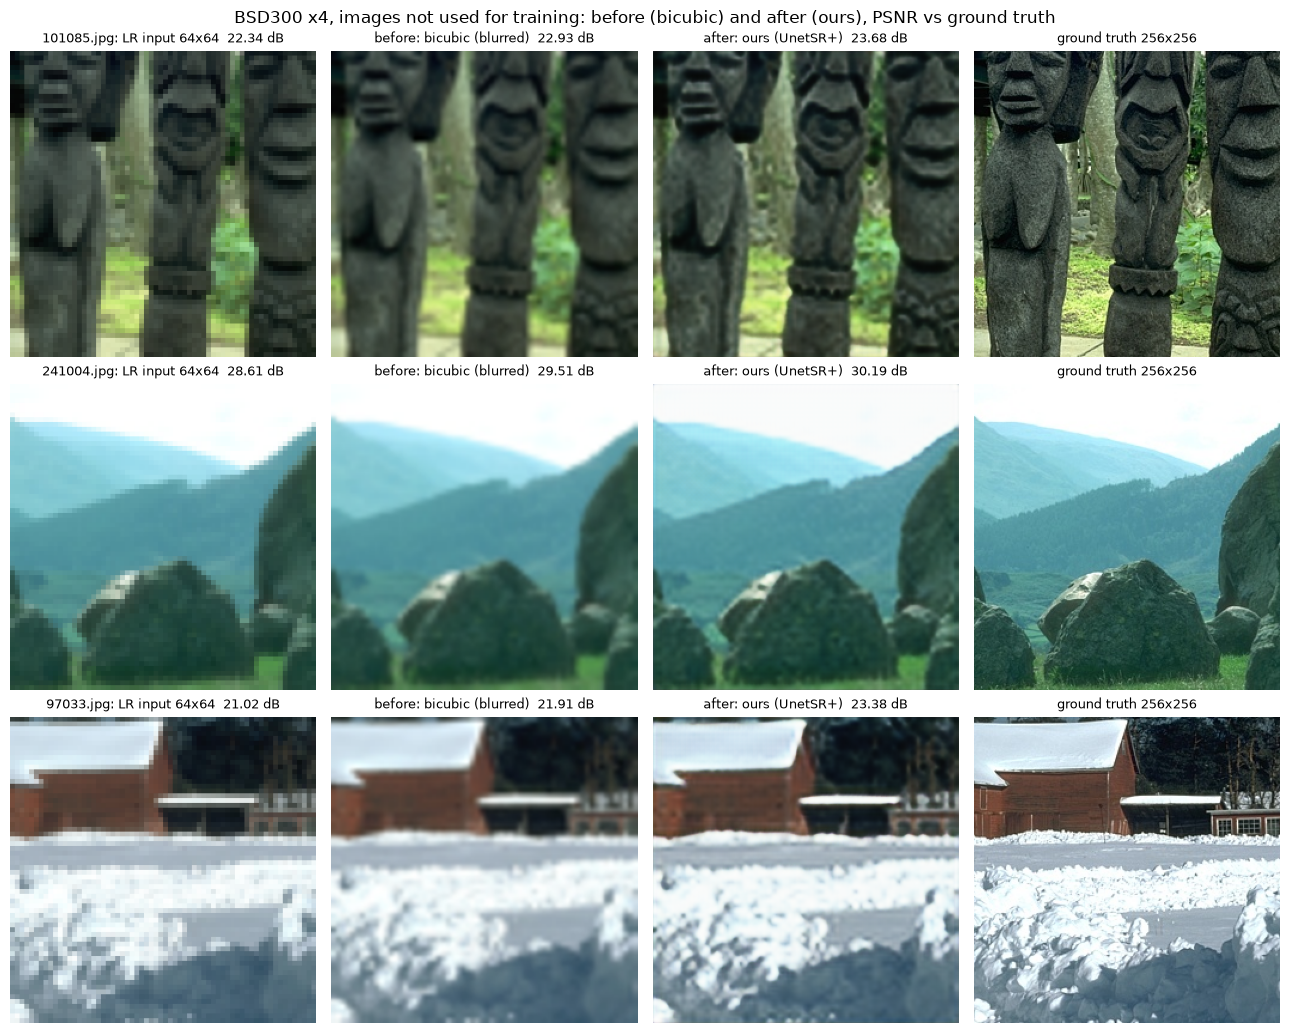

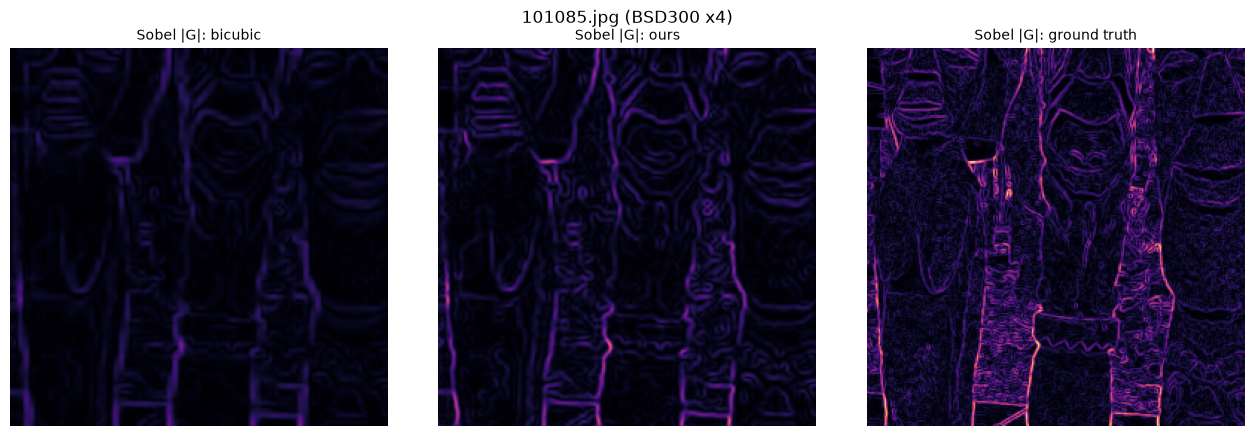

In [20]:
TRAIN_NAMES = {f.name for f in train_files} if MODE == "train" else set()   # the whole training split


def image_source(name):
    """Where the images of a test set come from (for the figure captions)."""
    if name == VAL_SET:
        return f"{DATASET} training images held out before training (VAL_HOLDOUT = {VAL_HOLDOUT})"
    if name == "SET14_ALL":
        return f"all 14 Set14 images ({DATA_DIR / 'SET14'}/train + test)"
    return f"the {name} test split ({DATA_DIR / name / 'test'})"


def unseen(name, ds):
    """Indices of the images of a test set that are not in the training split (SET14_ALL holds 11 of them)."""
    same = name.replace("_ALL", "") == DATASET
    return [i for i, n in enumerate(ds.names) if not (same and n in TRAIN_NAMES)]


def show_examples(rows, nets=None):
    """Before (LR input, bicubic up-scaling: blurred) and after (each net) for whole test images.

    rows: one (caption, dataset, index) per row; nets: {panel title: model}, by default our model."""
    nets = nets or {f"after: ours ({PAPER_METHOD or LOSS})": model}
    ncol = len(nets) + 3
    fig, axes = plt.subplots(len(rows), ncol, figsize=(3.25 * ncol, 3.4 * len(rows)), squeeze=False)
    for r, (caption, ds, i) in enumerate(rows):
        lr, hr = ds[i]
        H = hr.shape[-1]
        panels = [(f"{caption}: LR input {lr.shape[2]}x{lr.shape[1]}", F.interpolate(lr[None], size=H, mode="nearest")[0]),
                  ("before: bicubic (blurred)", bicubic_upscale(lr[None], H)[0])]
        for title, net in nets.items():
            net.eval()
            with torch.no_grad():
                panels.append((title, net(lr[None].to(DEVICE)).float().clamp(0, 1).cpu()[0]))
        panels.append((f"ground truth {H}x{H}", hr))
        for c, (title, img) in enumerate(panels):
            p = psnr(img[None], hr[None]).item()
            axes[r, c].imshow(img.permute(1, 2, 0).numpy())
            axes[r, c].set_title(title + ("" if c == ncol - 1 else f"  {p:.2f} dB"), fontsize=9)
            axes[r, c].axis("off")
    plt.tight_layout()
    return fig


if MODE == "train" and test_sets:
    for name, ds in test_sets.items():
        pool = unseen(name, ds)
        if not pool:
            print(f"{name}: every image is a training image - no examples shown")
            continue
        idx = [pool[k] for k in sorted(set(np.linspace(0, len(pool) - 1, 3).astype(int)))]
        print(f"{name} examples: {', '.join(ds.names[i] for i in idx)} - from {image_source(name)}; "
              f"none of them is among the {len(TRAIN_NAMES)} {DATASET} training images")
        fig = show_examples([(ds.names[i], ds, i) for i in idx])
        fig.suptitle(f"{name} x{SCALE}, images not used for training: before (bicubic) and after (ours), "
                     f"PSNR vs ground truth", y=1.01)
        fig.savefig(FIG_DIR / f"examples_{name}.png", dpi=120, bbox_inches="tight")
        plt.show()

    name, ds = next(iter(test_sets.items()))
    i = unseen(name, ds)[0]
    lr, hr = ds[i]
    with torch.no_grad():
        sr = model(lr[None].to(DEVICE)).float().clamp(0, 1).cpu()
    maps = [("bicubic", bicubic_upscale(lr[None], hr.shape[-1])), ("ours", sr), ("ground truth", hr[None])]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
    for ax, (title, img) in zip(axes, maps):
        g = gradient_magnitude(img).mean(1)[0]
        ax.imshow(g.numpy(), cmap="magma", vmin=0, vmax=float(gradient_magnitude(hr[None]).mean(1).max()))
        ax.set_title(f"Sobel |G|: {title}", fontsize=10)
        ax.axis("off")
    fig.suptitle(f"{ds.names[i]} ({name} x{SCALE})")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "gradient_maps.png", dpi=120)
    plt.show()

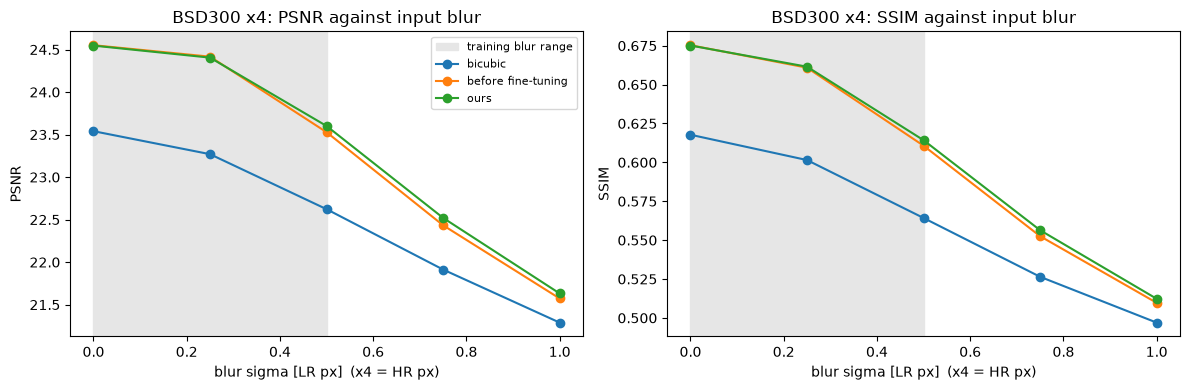

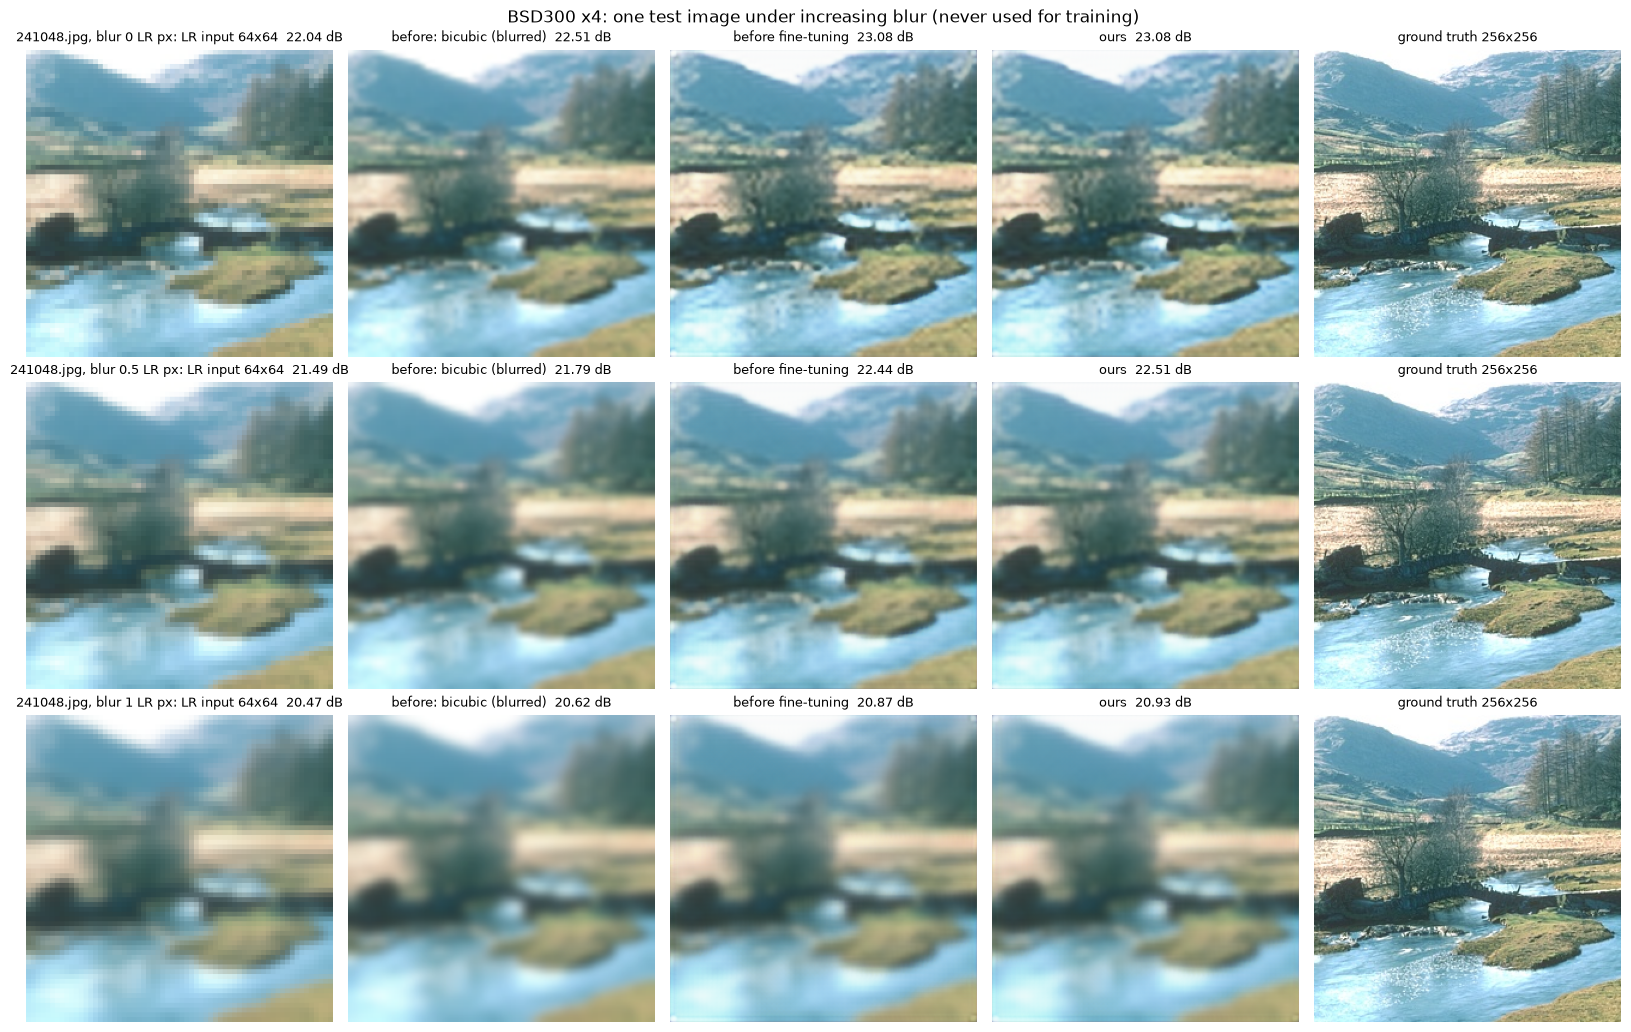

In [21]:
if MODE == "train" and not BLUR_SWEEP.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ("psnr", "ssim")):
        if DEGRADATION == "random":
            ax.axvspan(0, BLUR_MAX, color="0.9", label="training blur range")
        for who, g in BLUR_SWEEP.groupby("model", sort=False):
            ax.plot(g.sigma_lr, g[metric], marker="o", label=who)
        ax.set(xlabel=f"blur sigma [LR px]  (x{SCALE} = HR px)", ylabel=metric.upper(),
               title=f"{DATASET} x{SCALE}: {metric.upper()} against input blur")
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    fig.savefig(FIG_DIR / "blur_sweep.png", dpi=120)
    plt.show()

    i = len(BLUR_SETS[BLUR_TEST[0]]) // 2
    nets = {who: net for who, net in BLUR_NETS.items() if who != "bicubic"}
    shown = sorted({BLUR_TEST[0], BLUR_TEST[-1], *(b for b in BLUR_TEST if b == BLUR_MAX)})   # mildest, BLUR_MAX, strongest
    fig = show_examples([(f"{BLUR_SETS[b].names[i]}, blur {b:g} LR px", BLUR_SETS[b], i) for b in shown], nets)
    fig.suptitle(f"{DATASET} x{SCALE}: one test image under increasing blur (never used for training)", y=1.01)
    fig.savefig(FIG_DIR / "blur_examples.png", dpi=90, bbox_inches="tight")
    plt.show()


## 11 Super-resolve your own image
`super_resolve(path)` treats the image as the LR input and enlarges it `SCALE` times. The LR image is padded by edge
replication to a multiple of 16, because the U-net halves the size four times; the padding is cropped off the output
afterwards.

Keep in mind that the model learned from images that were shrunk with bilinear (or bicubic) interpolation.
Real-world photos are degraded differently, so expect weaker results on them. A model fine-tuned with
`DEGRADATION = "random"` has seen varied blur and down-samplers and copes better with them (section 9's blur
sweep), but it has never seen noise or JPEG artefacts.

The trained weights are saved as CPU tensors in `runs/<RUN_NAME>/unetsr_x<SCALE>_<LOSS>.pt`, so they load on any
machine:

```python
net = UNetSR(4)
net.load_state_dict(torch.load("runs/BSD300_x4_mixge/unetsr_x4_mixge.pt", weights_only=True))
super_resolve("my_photo.png", net=net.to(DEVICE), scale=4, out_path="my_photo_x4.png")
```

In [22]:
@torch.no_grad()
def super_resolve(path, net=None, scale=None, out_path=None):
    net, scale = (net or model).eval(), scale or SCALE
    lr = to_uint8_tensor(Image.open(path).convert("RGB")).float().div(255)[None].to(DEVICE)
    h, w = lr.shape[-2:]
    lr = F.pad(lr, (0, (-w) % 16, 0, (-h) % 16), mode="replicate")
    sr = net(lr).float()[..., : h * scale, : w * scale].clamp(0, 1)
    out = Image.fromarray(sr[0].mul(255).round().byte().permute(1, 2, 0).cpu().numpy())
    if out_path:
        out.save(out_path)
    return out


if MODE == "train" and test_sets:
    name, ds = next(iter(test_sets.items()))
    demo_lr = RUN_DIR / "demo_lr.png"
    Image.fromarray(ds.lr[0].permute(1, 2, 0).numpy()).save(demo_lr)
    demo_sr = super_resolve(demo_lr, out_path=RUN_DIR / "demo_sr.png")
    print(f"{demo_lr} {Image.open(demo_lr).size} -> {RUN_DIR / 'demo_sr.png'} {demo_sr.size}")

runs\BSD300_x4_mixge_rand_ft_lr0.0001\demo_lr.png (64, 64) -> runs\BSD300_x4_mixge_rand_ft_lr0.0001\demo_sr.png (256, 256)


## 12 Final results vs the paper
This section reads every `runs/*/metrics.json` and keeps only the **final** runs:

* no smoke tests, and the default training settings (fine-tuned runs may change the learning rate, its schedule and
  the degradation);
* for each dataset, scale, loss and degradation, the run with the most epochs, so a 300-epoch run replaces an earlier
  40-epoch one.

It writes two tables to `runs/summary.md` (minutes 1, 2 and 4c):

* **Table A, reproduction**: our final PSNR / SSIM next to the paper's Table 2 for bicubic, UnetSR (MSE) and UnetSR+
  (MixGE), with the difference in dB and the verdict of section 9, and the paper's best other method. For SET14 (and
  ICDAR2003) it also gives the PSNR of the BSD300-trained models on that test set, when they were scored on it
  (`-p EVAL_SETS "BSD300,SET14"`): 11 training images are very few, and the paper does not say what its SET14 models
  were trained on.
* **Table B, robustness to blur**: the PSNR of every final model on the blur sweep of section 9, with bicubic for
  reference.

Run the notebook once per configuration, by hand or with papermill, then re-run this cell. README §7 lists the whole
final grid. For example, BSD300 at all three scales and the two fine-tuned models:

```
# bash / zsh (Linux, macOS, WSL)
for s in 2 4 8; do for l in mse mixge; do
  uv run papermill SimplifiedUNetSR.ipynb runs/BSD300_x${s}_${l}.ipynb -p SCALE $s -p LOSS $l
done; done
for s in 2 4; do
  uv run papermill SimplifiedUNetSR.ipynb runs/BSD300_x${s}_mixge_ft.ipynb -p SCALE $s -p LOSS mixge \
    -p DEGRADATION random -p FINETUNE_FROM BSD300_x${s}_mixge -p LR 1e-4 -p EPOCHS 100
done

# Windows PowerShell
foreach ($s in 2,4,8) { foreach ($l in 'mse','mixge') {
  uv run papermill SimplifiedUNetSR.ipynb "runs/BSD300_x${s}_${l}.ipynb" -p SCALE $s -p LOSS $l } }
foreach ($s in 2,4) {
  uv run papermill SimplifiedUNetSR.ipynb "runs/BSD300_x${s}_mixge_ft.ipynb" -p SCALE $s -p LOSS mixge `
    -p DEGRADATION random -p FINETUNE_FROM "BSD300_x${s}_mixge" -p LR 1e-4 -p EPOCHS 100 }
```


Table A: final results vs the paper's Table 2 (PSNR dB / SSIM, RGB)


,dataset,scale,bicubic paper,bicubic ours,UnetSR paper,UnetSR ours,UnetSR Δ dB,UnetSR+ paper,UnetSR+ ours,UnetSR+ Δ dB,"UnetSR / UnetSR+ ours, BSD300-trained",best other method (paper)
0,BSD300,x2,26.65 / 0.7924,26.68 / 0.7938,29.42 / 0.8813,29.04 / 0.8726 (300 ep),-0.38 (close),29.84 / 0.8816,29.06 / 0.8735 (300 ep),-0.78 (close),-,DBPN 29.87 / 0.8834
1,BSD300,x4,23.51 / 0.6157,23.54 / 0.6178,24.83 / 0.6843,24.58 / 0.6755 (300 ep),-0.25 (matches),24.95 / 0.6901,24.55 / 0.6753 (300 ep),-0.40 (close),-,DBPN 25.06 / 0.6967
2,BSD300,x8,21.31 / 0.4933,21.34 / 0.4951,21.99 / 0.5231,22.03 / 0.5255 (300 ep),+0.04 (matches),22.04 / 0.5235,22.04 / 0.5263 (300 ep),+0.01 (matches),-,DBPN 22.06 / 0.5229
3,SET14,x2,24.45 / 0.8482,24.45 / 0.8482,26.72 / 0.8735,24.51 / 0.8441 (300 ep),-2.21 (differs),28.40 / 0.9198,24.43 / 0.8413 (300 ep),-3.96 (differs),28.84 / 28.92,VDSR 28.66 / 0.9269
4,SET14,x4,19.72 / 0.6089,19.72 / 0.6089,20.89 / 0.6693,18.55 / 0.5826 (300 ep),-2.34 (differs),21.68 / 0.7112,18.57 / 0.5819 (300 ep),-3.11 (differs),21.96 / 21.87,DBPN 21.77 / 0.7171
5,SET14,x8,16.11 / 0.3673,16.11 / 0.3673,16.70 / 0.4093,16.23 / 0.3727 (300 ep),-0.47 (close),17.83 / 0.4103,16.08 / 0.3689 (300 ep),-1.75 (differs),17.10 / 17.12,VDSR 16.80 / 0.4095


Table B: PSNR [dB] on the blur sweep (sigma in LR pixels; sigma = 0 is the paper's test set)


,dataset,scale,model,run,σ=0,σ=0.25,σ=0.5,σ=0.75,σ=1
0,BSD300,x2,bicubic,-,26.68,26.31,25.25,24.26,23.45
1,BSD300,x2,"UnetSR, fixed degradation",BSD300_x2_mse,29.04,28.80,26.85,25.01,23.82
3,BSD300,x2,"UnetSR+, fixed degradation",BSD300_x2_mixge,29.06,28.82,26.87,25.03,23.83
5,BSD300,x2,"UnetSR+, random blur, fine-tuned",BSD300_x2_mixge_rand_ft_lr0.0001,28.90,28.68,27.11,25.31,24.01
6,BSD300,x4,bicubic,-,23.54,23.27,22.62,21.91,21.29
7,BSD300,x4,"UnetSR, fixed degradation",BSD300_x4_mse,24.58,24.43,23.52,22.41,21.56
9,BSD300,x4,"UnetSR+, fixed degradation",BSD300_x4_mixge,24.55,24.42,23.53,22.43,21.57
11,BSD300,x4,"UnetSR+, random blur, fine-tuned",BSD300_x4_mixge_rand_ft_lr0.0001,24.55,24.40,23.60,22.52,21.63
12,BSD300,x8,bicubic,-,21.34,21.13,20.60,20.00,19.45
13,BSD300,x8,"UnetSR, fixed degradation",BSD300_x8_mse,22.03,21.92,21.24,20.37,19.66


saved runs\summary.md


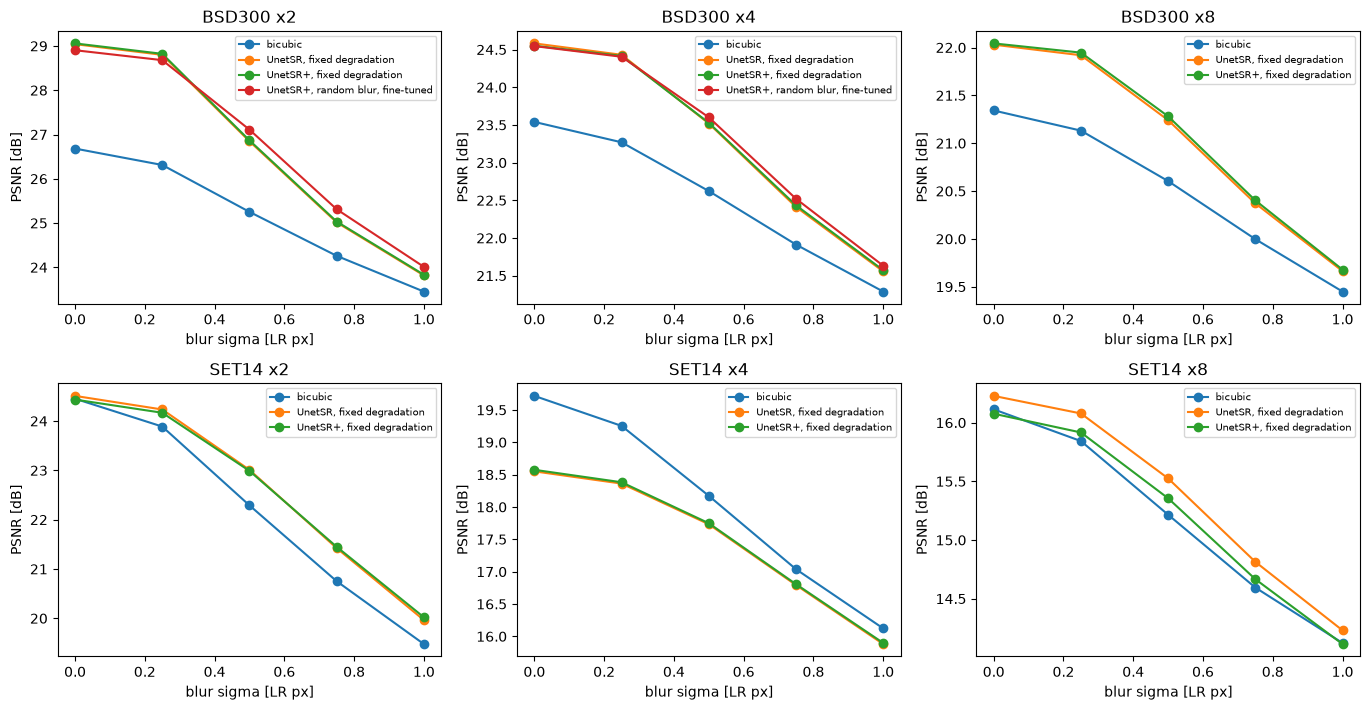

In [23]:
def markdown_table(df, digits=4):
    cols = list(df.columns)
    fmt = lambda v: "-" if v is None or (isinstance(v, float) and math.isnan(v)) else (
        f"{v:.{digits}f}" if isinstance(v, (float, np.floating)) else str(v))
    lines = ["| " + " | ".join(cols) + " |", "|" + "---|" * len(cols)]
    lines += ["| " + " | ".join(fmt(v) for v in row) + " |" for row in df.itertuples(index=False)]
    return "\n".join(lines)


PAPER_NAMES = {"mse": "UnetSR", "mixge": "UnetSR+"}
FREE_WHEN_FINETUNED = {"LR", "LR_STEP", "LR_GAMMA", "DEGRADATION", "BLUR_MAX", "FINETUNE_FROM"}


def final_runs(runs_dir=None):
    """{(dataset, scale, loss, degradation, fine-tuned): (run name, metrics)} of the final runs (see above)."""
    best = {}
    for f in sorted(Path(runs_dir or RUNS_DIR).glob("*/metrics.json")):
        m = json.loads(f.read_text())
        c = m["config"]
        ft = bool(c.get("FINETUNE_FROM"))
        free = FREE_WHEN_FINETUNED if ft else set()
        if (c["SMOKE_TEST"] or c["LOSS"] not in PAPER_NAMES or c["PROTOCOL"] != auto_protocol(c["DATASET"])
                or any(c.get(k, v) != v for k, v in DEFAULTS.items() if k not in free)):
            continue
        key = (c["DATASET"], c["SCALE"], c["LOSS"], c.get("DEGRADATION", "fixed"), ft)
        if key not in best or m["epochs_trained"] > best[key][1]["epochs_trained"]:
            best[key] = (f.parent.name, m)
    return best


def pair(psnr_value, ssim_value):
    return f"{psnr_value:.2f} / {ssim_value:.4f}"


FINAL = final_runs()
rows = []                                                   # Table A: reproduction of the paper's Table 2
for ds_name in ("BSD300", "SET14", "ICDAR2003"):
    for s in (2, 4, 8):
        found = {loss: FINAL.get((ds_name, s, loss, "fixed", False)) for loss in PAPER_NAMES}
        found = {loss: v for loss, v in found.items() if v and ds_name in v[1]["results"]}
        if not found:
            continue
        row = dict(dataset=ds_name, scale=f"x{s}", **{"bicubic paper": pair(*PAPER[("Bicubic", s, ds_name)])})
        for loss, method in PAPER_NAMES.items():
            row[f"{method} paper"] = pair(*PAPER[(method, s, ds_name)])
            if loss in found:
                run, m = found[loss]
                r = m["results"][ds_name]
                row["bicubic ours"] = pair(r["bicubic_psnr"], r["bicubic_ssim"])
                row[f"{method} ours"] = f"{pair(r['psnr'], r['ssim'])} ({m['epochs_trained']} ep)"
                row[f"{method} Δ dB"] = f"{r['d_psnr']:+.2f} ({r['verdict_absolute']})"
        cross = [FINAL.get(("BSD300", s, loss, "fixed", False)) for loss in PAPER_NAMES]
        if ds_name != "BSD300" and all(c and ds_name in c[1]["results"] for c in cross):
            row["UnetSR / UnetSR+ ours, BSD300-trained"] = " / ".join(
                f"{c[1]['results'][ds_name]['psnr']:.2f}" for c in cross)
        others = {m: v for (m, sc, d), v in PAPER.items()
                  if sc == s and d == ds_name and m not in ("Bicubic", "UnetSR", "UnetSR+")}
        top = max(others, key=lambda m: others[m][0])
        row["best other method (paper)"] = f"{top} {pair(*others[top])}"
        rows.append(row)
TABLE_A = pd.DataFrame(rows, columns=["dataset", "scale", "bicubic paper", "bicubic ours", "UnetSR paper", "UnetSR ours",
                                      "UnetSR Δ dB", "UnetSR+ paper", "UnetSR+ ours", "UnetSR+ Δ dB",
                                      "UnetSR / UnetSR+ ours, BSD300-trained", "best other method (paper)"])

rows = []                                                   # Table B: PSNR on the blur sweep
for (ds_name, s, loss, degradation, ft), (run, m) in sorted(FINAL.items(), key=lambda kv: (
        kv[0][0], kv[0][1], list(PAPER_NAMES).index(kv[0][2]), kv[0][3], kv[0][4])):
    sweep = pd.DataFrame(m.get("blur_sweep", []))
    if sweep.empty:
        continue
    for who in ("bicubic", "ours"):
        g = sweep[sweep.model == who]
        label = "bicubic" if who == "bicubic" else (
            f"{PAPER_NAMES[loss]}, " + ("random blur, fine-tuned" if ft else f"{degradation} degradation"))
        rows.append(dict(dataset=ds_name, scale=f"x{s}", model=label, run="-" if who == "bicubic" else run,
                         **{f"σ={b:g}": p for b, p in zip(g.sigma_lr, g.psnr)}))
TABLE_B = pd.DataFrame(rows).drop_duplicates(subset=["dataset", "scale", "model"]) if rows else pd.DataFrame()

if TABLE_A.empty and TABLE_B.empty:
    print("no finished runs yet")
else:
    print("Table A: final results vs the paper's Table 2 (PSNR dB / SSIM, RGB)")
    display(TABLE_A.fillna("-"))
    print("Table B: PSNR [dB] on the blur sweep (sigma in LR pixels; sigma = 0 is the paper's test set)")
    display(TABLE_B.round(2))
    (Path(RUNS_DIR) / "summary.md").write_text(
        "## Table A: final results vs the paper's Table 2 (PSNR dB / SSIM, RGB)\n\n" + markdown_table(TABLE_A)
        + "\n\n## Table B: PSNR [dB] on the blur sweep (σ in LR pixels; σ = 0 is the paper's test set)\n\n"
        + markdown_table(TABLE_B, digits=2) + "\n", encoding="utf-8")
    print(f"saved {Path(RUNS_DIR) / 'summary.md'}")

if not TABLE_B.empty:
    groups = list(TABLE_B.groupby(["dataset", "scale"], sort=False))
    sig_cols = [c for c in TABLE_B.columns if c.startswith("σ=")]
    ncols = min(3, len(groups))
    fig, axes = plt.subplots(math.ceil(len(groups) / ncols), ncols, figsize=(4.6 * ncols, 3.6 * math.ceil(len(groups) / ncols)),
                             squeeze=False)
    for ax, ((d, s), g) in zip(axes.flat, groups):
        for _, r in g.iterrows():
            ax.plot([float(c[2:]) for c in sig_cols], r[sig_cols].astype(float), marker="o", label=r.model)
        ax.set(title=f"{d} {s}", xlabel="blur sigma [LR px]", ylabel="PSNR [dB]")
        ax.legend(fontsize=7)
    for ax in axes.flat[len(groups):]:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(Path(RUNS_DIR) / "summary_blur.png", dpi=120)
    plt.show()


## 13 Try this
1. **UnetSR vs UnetSR+.** Train `LOSS="mse"` and `LOSS="mixge"` at the same scale. Does the gradient term buy the
   +0.4 dB (BSD300 ×2) or +2.5 dB (ICDAR2003 ×8) that the paper reports? Compare the gradient maps.
2. **λ<sub>G</sub> sweep.** Train with `LAMBDA_G` ∈ {1e-4, 1e-3, 1e-2, 1e-1, 1} at ×2 and reproduce the paper's
   Fig. 4. The paper holds out 50 training images for this study: set `VAL_HOLDOUT = 50` and read the scores of
   `BSD300_VAL`. Every value gets its own run folder. Repeat with `SOBEL_NORM=False`: where does the curve peak now?
3. **Text vs natural images.** Train on `DATASET="ICDAR2003"`. The paper's largest gains are on text.
4. **Protocol sensitivity.** Retrain with `PROTOCOL="paper_text"`: the 224-pixel bicubic setup the paper describes.
   How far do the bicubic and model PSNR move? Which would you report?
5. **Harder degradations.** Add Gaussian noise and JPEG compression to `random_lr` (Real-ESRGAN's ranges are in
   section 3b), or anisotropic blur kernels as in SRMD, and extend the blur sweep to match.
6. **Random blur from scratch.** Train with `DEGRADATION="random"` for 300 epochs without `FINETUNE_FROM`. Does
   fine-tuning reach the same robustness in a third of the epochs?
7. **Beyond the paper.** Set `AUGMENT=True`, use a larger `BATCH_SIZE` with a proportionally larger `LR`, or train on
   random patches of the full-resolution images, and evaluate on full-size images with the Y-channel metrics.